In [ ]:
import pandas as pd
import numpy as np
import os
print("1. O Python está olhando a partir da pasta:", os.getcwd())
print("2. O que tem dentro dessa pasta:", os.listdir('.'))

# 1. MAPEAMENTO DE CAMINHOS 
# O notebook está em /notebooks, então voltamos um nível (../) para acessar /data
caminho_entrada = '../data/raw/T12 CONTROLE.xlsx'
caminho_saida = '../data/csv/T12_CONTROLE_convertido.csv'
pasta_saida = '../data/csv'

# Garantir que a pasta de destino exista antes de tentar salvar
if not os.path.exists(pasta_saida):
    os.makedirs(pasta_saida)
    print(f"Diretório criado: {pasta_saida}")

# 2. CARREGAMENTO DOS DADOS E DIAGNÓSTICO
print(f"Iniciando a leitura do arquivo: {caminho_entrada}")
print("Aguarde, arquivos .xlsx podem ser lentos para carregar...")

try:
    # Tentativa 1: Forçar o motor padrão de Excel (openpyxl)
    df = pd.read_excel(caminho_entrada, engine='openpyxl')
    print(f"\n✅ Leitura concluída como Excel! O arquivo contém {len(df)} linhas.")

except ValueError as e:
    print(f"\n❌ Erro de Valor retornado pelo pandas: {e}")
    print("\n🔍 Investigando a estrutura real do arquivo...")
    
    # Tentativa 2: Ler os primeiros 150 caracteres do arquivo como se fosse texto bruto
    try:
        with open(caminho_entrada, 'r', encoding='utf-8') as f:
            cabecalho_real = f.read(150)
            print("--- CONTEÚDO BRUTO DO ARQUIVO ---")
            print(cabecalho_real)
            print("---------------------------------")
            print("Diagnóstico: O seu arquivo provavelmente é um arquivo de texto (CSV/TSV) disfarçado de Excel.")
    except UnicodeDecodeError:
        print("Diagnóstico: O arquivo é binário, não é texto. Pode estar corrompido ou requer uma versão antiga do Excel (xls).")

# 3. APLICAÇÃO DO PROTOCOLO DE REQUISITOS (Verificação da Amostragem)
# A coluna 'Timegap (ms)' nos diz o tempo entre as capturas.
# Pelo nosso protocolo, gaps maiores que 100ms são considerados perdas de sinal/piscadas, 
# e não refletem a velocidade do hardware. Vamos isolar o comportamento normal.

# Filtra apenas os gaps menores ou iguais a 100ms
gaps_validos = df[df['Timegap (ms)'] <= 100]['Timegap (ms)']

media_gap_real = gaps_validos.mean()
# Calcula os Hz (1000 milissegundos divididos pelo tempo médio do gap)
taxa_hz_real = 1000 / media_gap_real 

print("\n--- 📊 RELATÓRIO DE QUALIDADE DO EQUIPAMENTO ---")
print("Equipamento: Eye-Tech TM3 (Nominal: 60 Hz)")
print(f"Média do gap de tempo (capturas normais): {media_gap_real:.2f} ms")
print(f"Taxa de amostragem REAL calculada: {taxa_hz_real:.2f} Hz")

# 4. EXPLORAÇÃO INICIAL DE RUÍDO
# Vamos olhar rapidamente para a coluna 'Detection' para entender como o tracker registra perdas.
print("\n--- ⚠️ ANÁLISE DE PERDA DE SINAL ---")
if 'Detection' in df.columns:
    print("Valores encontrados na coluna 'Detection' e suas quantidades:")
    print(df['Detection'].value_counts())
else:
    print("Atenção: Coluna 'Detection' não encontrada neste arquivo.")

# 5. CONVERSÃO E EXPORTAÇÃO
print("\nSalvando arquivo convertido...")
# Salvamos em CSV para acelerar todas as próximas etapas (index=False não cria coluna extra)
df.to_csv(caminho_saida, index=False)
print(f"✅ Conversão concluída com sucesso! Arquivo salvo em: {caminho_saida}")

1. O Python está olhando a partir da pasta: /workspaces/EyeTracking_analysis/notebooks
2. O que tem dentro dessa pasta: ['fase1_conversao.ipynb']
Iniciando a leitura do arquivo: ../data/raw/T12 CONTROLE.xlsx
Aguarde, arquivos .xlsx podem ser lentos para carregar...


BadZipFile: File is not a zip file

In [9]:
caminho_entrada = '../data/raw/T12 CONTROLE.xlsx'

print("🔍 Investigando a verdadeira estrutura do arquivo...\n")

try:
    # Vamos tentar forçar a leitura do arquivo como se ele fosse um arquivo de texto comum
    with open(caminho_entrada, 'r', encoding='utf-8') as f:
        cabecalho = f.read(500) # Lê os primeiros 500 caracteres
        print("✅ DIAGNÓSTICO: O arquivo é texto puro (CSV/TSV disfarçado).")
        print("\n--- INÍCIO DO CONTEÚDO BRUTO ---")
        print(cabecalho)
        print("--------------------------------")
except UnicodeDecodeError:
    print("⚠️ DIAGNÓSTICO: O arquivo é binário. Pode ser um formato muito antigo do Excel (.xls) ou foi corrompido no upload.")
    with open(caminho_entrada, 'rb') as f:
        print(f"Assinatura em bytes: {f.read(30)}")
except Exception as e:
    print(f"Erro inesperado: {e}")

🔍 Investigando a verdadeira estrutura do arquivo...

⚠️ DIAGNÓSTICO: O arquivo é binário. Pode ser um formato muito antigo do Excel (.xls) ou foi corrompido no upload.
Assinatura em bytes: b'\x00\x00\x00\x1cftypisom\x00\x00\x02\x00isomiso2mp41\x00\x00'


In [10]:
# 1. COLOQUE O NOME DO NOVO ARQUIVO AQUI
caminho_entrada = '../data/raw/T43 CONTROLE.xlsx'

print(f"🔍 Investigando a estrutura do arquivo: {caminho_entrada}\n")

try:
    # Tenta ler como texto (CSV/TSV disfarçado)
    with open(caminho_entrada, 'r', encoding='utf-8') as f:
        cabecalho = f.read(500)
        print("✅ SUCESSO: Este arquivo contém dados em formato de texto. Achamos o log!")
        print("\n--- INÍCIO DO CONTEÚDO BRUTO ---")
        print(cabecalho)
        print("--------------------------------")
except UnicodeDecodeError:
    # Se falhar, tenta ler os bytes para ver se é outro vídeo
    print("⚠️ DIAGNÓSTICO: Este arquivo também é binário (provavelmente outro vídeo).")
    with open(caminho_entrada, 'rb') as f:
        print(f"Assinatura em bytes: {f.read(30)}")
except FileNotFoundError:
    print("❌ ERRO: Arquivo não encontrado. Verifique se o nome do arquivo na linha 2 está escrito exatamente igual ao que está na pasta data/raw.")
except Exception as e:
    print(f"Erro inesperado: {e}")

🔍 Investigando a estrutura do arquivo: ../data/raw/T43 CONTROLE.xlsx

⚠️ DIAGNÓSTICO: Este arquivo também é binário (provavelmente outro vídeo).
Assinatura em bytes: b'PK\x03\x04\x14\x00\x08\x08\x08\x00IZ\x97\\\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x18\x00\x00\x00'


In [ ]:
import pandas as pd
import numpy as np
import os

# 1. MAPEAMENTO DE CAMINHOS
caminho_entrada = '../data/raw/T43 CONTROLE.xlsx'
caminho_saida = '../data/csv/T43_CONTROLE_convertido.csv'
pasta_saida = '../data/csv'

# Garantir que exista a pasta de destino
if not os.path.exists(pasta_saida):
    os.makedirs(pasta_saida)

# 2. CARREGAMENTO DOS DADOS (Agora com o motor correto para arquivos PK/ZIP)
print(f"Iniciando a leitura do arquivo Excel verdadeiro: {caminho_entrada}")
print("Aguarde, extraindo dados do formato .xlsx...")

# Usamos o motor openpyxl, que é o padrão do Python para ler as estruturas ZIP do Excel
df = pd.read_excel(caminho_entrada, engine='openpyxl')
total_linhas = len(df)
print(f"\n✅ Leitura concluída! O arquivo contém {total_linhas} linhas de registro.")

# 3. APLICAÇÃO DO PROTOCOLO DE REQUISITOS (Verificação da Amostragem)
print("\n--- 📊 RELATÓRIO DE QUALIDADE DO EQUIPAMENTO ---")
if 'Timegap (ms)' in df.columns:
    # Filtramos gaps maiores que 100ms (piscadas/perdas) para achar o ritmo normal da máquina
    gaps_validos = df[df['Timegap (ms)'] <= 100]['Timegap (ms)']
    media_gap_real = gaps_validos.mean()
    taxa_hz_real = 1000 / media_gap_real 
    
    print("Equipamento: Eye-Tech TM3 (Nominal: 60 Hz)")
    print(f"Média do gap de tempo (capturas normais): {media_gap_real:.2f} ms")
    print(f"Taxa de amostragem REAL calculada: {taxa_hz_real:.2f} Hz")
else:
    print("Atenção: Coluna 'Timegap (ms)' não encontrada.")

# 4. EXPLORAÇÃO INICIAL DE RUÍDO
print("\n--- ⚠️ ANÁLISE DE PERDA DE SINAL ---")
# Na sua imagem, vi que existem hifens '-' na coluna AOI e valores 0 em coordenadas.
# Vamos mapear se há uma coluna específica de detecção ou contar as falhas de captura.
if 'Duration' in df.columns:
    zeros_duration = (df['Duration'] == 0).sum()
    print(f"Linhas com Duração = 0 (possível ausência de fixação/dado bruto cru): {zeros_duration}")

# 5. CONVERSÃO E EXPORTAÇÃO
print("\nSalvando arquivo convertido...")
df.to_csv(caminho_saida, index=False)
print(f"✅ Conversão concluída com sucesso! Arquivo otimizado salvo em: {caminho_saida}")

Iniciando a leitura do arquivo Excel verdadeiro: ../data/raw/T43 CONTROLE.xlsx
Aguarde, extraindo dados do formato .xlsx...

✅ Leitura concluída! O arquivo contém 11061 linhas de registro.

--- 📊 RELATÓRIO DE QUALIDADE DO EQUIPAMENTO ---
Equipamento: Eye-Tech TM3 (Nominal: 60 Hz)
Média do gap de tempo (capturas normais): 17.21 ms
Taxa de amostragem REAL calculada: 58.09 Hz

--- ⚠️ ANÁLISE DE PERDA DE SINAL ---
Linhas com Duração = 0 (possível ausência de fixação/dado bruto cru): 2

Salvando arquivo convertido...
✅ Conversão concluída com sucesso! Arquivo otimizado salvo em: ../data/csv/T43_CONTROLE_convertido.csv


In [12]:
import pandas as pd
import numpy as np

# 1. CARREGAMENTO DO ARQUIVO CONVERTIDO DA FASE 1
caminho_csv = '../data/csv/T43_CONTROLE_convertido.csv'
df = pd.read_csv(caminho_csv)

print("--- 🔍 MAPEAMENTO DE RUÍDOS E PISCADAS ---")

# 2. ANÁLISE DE COORDENADAS (Gaze X e Gaze Y)
# Contando valores zero, vazios (NaN) ou strings estranhas
zeros_x = (df['Gaze X'] == 0).sum()
zeros_y = (df['Gaze Y'] == 0).sum()
nulos_x = df['Gaze X'].isna().sum()

print(f"Coordenada Gaze X == 0: {zeros_x} linhas")
print(f"Coordenada Gaze Y == 0: {zeros_y} linhas")
print(f"Coordenadas Vazias (NaN): {nulos_x} linhas")

# 3. ANÁLISE DE PUPILA (Se houver diâmetro 0, o rastreador perdeu o olho)
if 'Pupil Diameter Left (mm)' in df.columns:
    zeros_pupila = (df['Pupil Diameter Left (mm)'] == 0).sum()
    nulos_pupila = df['Pupil Diameter Left (mm)'].isna().sum()
    print(f"\nDiâmetro Pupilar Esquerdo == 0: {zeros_pupila} linhas")
    print(f"Diâmetro Pupilar Vazio (NaN): {nulos_pupila} linhas")
else:
    print("\nAviso: Coluna 'Pupil Diameter Left (mm)' não encontrada com este nome exato.")

# 4. BUSCA POR CARACTERES ESPECIAIS (Hifens)
# Como vi hifens na sua captura de tela, vamos checar se eles poluem os dados
tem_hifen = df.apply(lambda col: col.astype(str).str.contains('-').any()).sum()
print(f"\nExistem {tem_hifen} colunas que contêm o caractere '-' (hífen).")

--- 🔍 MAPEAMENTO DE RUÍDOS E PISCADAS ---
Coordenada Gaze X == 0: 0 linhas
Coordenada Gaze Y == 0: 0 linhas
Coordenadas Vazias (NaN): 0 linhas

Diâmetro Pupilar Esquerdo == 0: 103 linhas
Diâmetro Pupilar Vazio (NaN): 0 linhas

Existem 4 colunas que contêm o caractere '-' (hífen).


In [13]:
import pandas as pd
import numpy as np

# 1. CARREGAMENTO DOS DADOS
caminho_csv = '../data/csv/T43_CONTROLE_convertido.csv'
caminho_saida = '../data/csv/T43_CONTROLE_limpo.csv'

print("Iniciando a Fase 2: Limpeza e Interpolação Fisiológica...")
df = pd.read_csv(caminho_csv)

# 2. SANITIZAÇÃO DE CARACTERES (Regra 1)
# O Pandas pode ter lido colunas com hífen '-' como texto. Vamos forçar a conversão 
# para NaN (Not a Number) para podermos fazer matemática com elas.
df.replace('-', np.nan, inplace=True)

# 3. INVALIDAÇÃO DE DADOS FALSOS (Regra 2)
col_pupila = 'Pupil Diameter Left (mm)'
# Garante que a coluna de pupila é lida como número
df[col_pupila] = pd.to_numeric(df[col_pupila], errors='coerce')

# Conta quantas linhas têm o olho perdido antes da limpeza
perdas_iniciais = (df[col_pupila] == 0).sum() + df[col_pupila].isna().sum()

# Onde a pupila for 0 ou NaN, transformamos X e Y em NaN (destruindo o dado falso)
mascara_perda = (df[col_pupila] == 0) | (df[col_pupila].isna())
df.loc[mascara_perda, ['Gaze X', 'Gaze Y']] = np.nan

# 4. INTERPOLAÇÃO LINEAR (Regras 3 e 4)
# Limite de 24 frames corresponde a ~413 ms na sua taxa real de 58 Hz.
# Qualquer buraco menor que 24 linhas será preenchido com uma reta ligando os pontos.
df['Gaze X'] = pd.to_numeric(df['Gaze X'], errors='coerce')
df['Gaze Y'] = pd.to_numeric(df['Gaze Y'], errors='coerce')

df['Gaze X'] = df['Gaze X'].interpolate(method='linear', limit=24, limit_direction='forward')
df['Gaze Y'] = df['Gaze Y'].interpolate(method='linear', limit=24, limit_direction='forward')

# 5. AUDITORIA DOS RESULTADOS
# Vamos verificar o que sobrou após o algoritmo tentar "costurar" as piscadas.
perdas_finais = df['Gaze X'].isna().sum()
linhas_recuperadas = perdas_iniciais - perdas_finais

print("\n--- 🛠️ RELATÓRIO DE LIMPEZA METODOLÓGICA ---")
print(f"Total de falhas detectadas (Pupila = 0): {perdas_iniciais} frames.")
print(f"Frames recuperados por interpolação de piscadas (<= 400ms): {linhas_recuperadas} frames.")
print(f"Perdas definitivas (buracos longos, track loss > 400ms): {perdas_finais} frames.")

# 6. SALVAMENTO
df.to_csv(caminho_saida, index=False)
print(f"\n✅ Arquivo limpo e estruturado salvo em: {caminho_saida}")

Iniciando a Fase 2: Limpeza e Interpolação Fisiológica...

--- 🛠️ RELATÓRIO DE LIMPEZA METODOLÓGICA ---
Total de falhas detectadas (Pupila = 0): 103 frames.
Frames recuperados por interpolação de piscadas (<= 400ms): 103 frames.
Perdas definitivas (buracos longos, track loss > 400ms): 0 frames.

✅ Arquivo limpo e estruturado salvo em: ../data/csv/T43_CONTROLE_limpo.csv


In [1]:
import pandas as pd
import numpy as np

# 1. CARREGAMENTO DOS DADOS LIMPOS DA FASE 2
caminho_entrada = '../data/csv/T43_CONTROLE_limpo.csv'
caminho_saida = '../data/csv/T43_CONTROLE_features.csv'

print("Iniciando a Fase 3: Algoritmo de Classificação I-VT (Velocity Threshold)...")
df = pd.read_csv(caminho_entrada)

# 2. CÁLCULO DE DISTÂNCIA E VELOCIDADE (A Física do Olho)
# Usamos o Teorema de Pitágoras para calcular a distância percorrida em pixels 
# entre a linha atual e a linha anterior.
df['Delta_X'] = df['Gaze X'].diff()
df['Delta_Y'] = df['Gaze Y'].diff()
df['Distancia_px'] = np.sqrt(df['Delta_X']**2 + df['Delta_Y']**2)

# Calculamos a velocidade (Pixels por Segundo)
# Usamos a coluna 'Timegap (ms)' para saber o tempo exato entre as capturas
df['Velocidade_px_s'] = (df['Distancia_px'] / df['Timegap (ms)']) * 1000

# 3. APLICAÇÃO DO LIMIAR DE VELOCIDADE (O Filtro Cognitivo)
# A literatura geralmente define sacadas como movimentos mais rápidos que ~300 graus/segundo.
# Em pixels (variando pela resolução da tela e distância do sujeito), um limiar seguro 
# para iniciar a separação é de 250 a 300 pixels por segundo.
LIMIAR_VELOCIDADE = 250

# Criamos uma nova coluna chamada 'Evento_Cognitivo' e preenchemos tudo como 'Indefinido'
df['Evento_Cognitivo'] = 'Indefinido'

# Regra A: Se a velocidade for MENOR que o limiar -> Fixação
df.loc[df['Velocidade_px_s'] <= LIMIAR_VELOCIDADE, 'Evento_Cognitivo'] = 'Fixação'

# Regra B: Se a velocidade for MAIOR que o limiar -> Sacada
df.loc[df['Velocidade_px_s'] > LIMIAR_VELOCIDADE, 'Evento_Cognitivo'] = 'Sacada'

# Regra C: Se o Gaze X for nulo (lembra das perdas > 400ms?), o evento é 'Perda de Sinal'
df.loc[df['Gaze X'].isna(), 'Evento_Cognitivo'] = 'Perda de Sinal'

# 4. AUDITORIA E RELATÓRIO
total_linhas = len(df)
contagem_eventos = df['Evento_Cognitivo'].value_counts()

print("\n--- 🧠 RELATÓRIO DE ASSINATURAS COGNITIVAS ---")
print(f"Total de registros analisados: {total_linhas}")
print("\nDistribuição dos eventos:")
for evento, quantidade in contagem_eventos.items():
    porcentagem = (quantidade / total_linhas) * 100
    print(f"- {evento}: {quantidade} frames ({porcentagem:.1f}%)")

# 5. SALVAMENTO DA MATRIZ DE FEATURES
df.to_csv(caminho_saida, index=False)
print(f"\n✅ Matriz de features salva em: {caminho_saida}")

Iniciando a Fase 3: Algoritmo de Classificação I-VT (Velocity Threshold)...

--- 🧠 RELATÓRIO DE ASSINATURAS COGNITIVAS ---
Total de registros analisados: 11061

Distribuição dos eventos:
- Sacada: 10027 frames (90.7%)
- Fixação: 1033 frames (9.3%)
- Indefinido: 1 frames (0.0%)

✅ Matriz de features salva em: ../data/csv/T43_CONTROLE_features.csv


In [2]:
import pandas as pd
import numpy as np

# 1. CARREGAMENTO DOS DADOS LIMPOS
caminho_entrada = '../data/csv/T43_CONTROLE_limpo.csv'
caminho_saida_base = '../data/csv/T43_CONTROLE_features' # Não colocamos .csv ainda, pois salvaremos com o limiar escolhido

print("Iniciando a Fase 3 v2.0: Suavização e Teste de Limiares I-VT...\n")
df = pd.read_csv(caminho_entrada)

# 2. FILTRO DE SUAVIZAÇÃO (SMOOTHING) PARA REDUZIR JITTER
# Usamos uma janela de 3 frames (~50ms) centralizada para não atrasar o sinal.
# min_periods=1 garante que as bordas ou vizinhos de NaN não sejam perdidos.
df['Gaze X_Smooth'] = df['Gaze X'].rolling(window=3, center=True, min_periods=1).mean()
df['Gaze Y_Smooth'] = df['Gaze Y'].rolling(window=3, center=True, min_periods=1).mean()

# 3. CÁLCULO DE FÍSICA CORRIGIDO (Usando os dados suavizados)
df['Delta_X'] = df['Gaze X_Smooth'].diff()
df['Delta_Y'] = df['Gaze Y_Smooth'].diff()
df['Distancia_px'] = np.sqrt(df['Delta_X']**2 + df['Delta_Y']**2)

# Evita divisão por zero caso o Timegap seja 0 em algum frame anômalo
df['Timegap (ms)'] = df['Timegap (ms)'].replace(0, np.nan)
df['Velocidade_px_s'] = (df['Distancia_px'] / df['Timegap (ms)']) * 1000

# 4. CALIBRADOR DE LIMIARES (Threshold Sweep)
limiares_para_testar = [250, 500, 750, 1000]
total_linhas = len(df)

print("--- 🧠 TESTE COMPARATIVO DE LIMIARES DE VELOCIDADE ---")
print("Objetivo Fisiológico: Encontrar o limiar que resulte entre 70% e 90% de Fixações.\n")

for limiar in limiares_para_testar:
    # Cria uma coluna temporária para este teste
    col_teste = f'Evento_{limiar}'
    df[col_teste] = 'Indefinido'
    
    # Aplica as regras
    df.loc[df['Velocidade_px_s'] <= limiar, col_teste] = 'Fixação'
    df.loc[df['Velocidade_px_s'] > limiar, col_teste] = 'Sacada'
    df.loc[df['Gaze X'].isna(), col_teste] = 'Perda de Sinal'
    
    # Calcula as porcentagens
    fixacoes = (df[col_teste] == 'Fixação').sum()
    sacadas = (df[col_teste] == 'Sacada').sum()
    pct_fix = (fixacoes / total_linhas) * 100
    pct_sac = (sacadas / total_linhas) * 100
    
    print(f"Limiar de {limiar} px/s  ->  Fixações: {pct_fix:.1f}%  |  Sacadas: {pct_sac:.1f}%")

print("\n-----------------------------------------------------------")
print("AGUARDANDO DECISÃO DO PESQUISADOR:")
print("Analise as porcentagens acima. Qual dos limiares chegou mais perto da métrica esperada (70-90% de fixação)?")

Iniciando a Fase 3 v2.0: Suavização e Teste de Limiares I-VT...

--- 🧠 TESTE COMPARATIVO DE LIMIARES DE VELOCIDADE ---
Objetivo Fisiológico: Encontrar o limiar que resulte entre 70% e 90% de Fixações.

Limiar de 250 px/s  ->  Fixações: 41.9%  |  Sacadas: 58.1%
Limiar de 500 px/s  ->  Fixações: 70.9%  |  Sacadas: 29.1%
Limiar de 750 px/s  ->  Fixações: 79.3%  |  Sacadas: 20.6%
Limiar de 1000 px/s  ->  Fixações: 83.3%  |  Sacadas: 16.7%

-----------------------------------------------------------
AGUARDANDO DECISÃO DO PESQUISADOR:
Analise as porcentagens acima. Qual dos limiares chegou mais perto da métrica esperada (70-90% de fixação)?


In [3]:
import pandas as pd
import numpy as np

# 1. CARREGAMENTO
caminho_entrada = '../data/csv/T43_CONTROLE_limpo.csv'
caminho_saida = '../data/csv/T43_CONTROLE_features.csv'

print("Iniciando a Fase 3: Extração Definitiva de Features (I-VT)...")
df = pd.read_csv(caminho_entrada)

# 2. SUAVIZAÇÃO (Janela de 3 frames)
df['Gaze X_Smooth'] = df['Gaze X'].rolling(window=3, center=True, min_periods=1).mean()
df['Gaze Y_Smooth'] = df['Gaze Y'].rolling(window=3, center=True, min_periods=1).mean()

# 3. FÍSICA E VELOCIDADE
df['Delta_X'] = df['Gaze X_Smooth'].diff()
df['Delta_Y'] = df['Gaze Y_Smooth'].diff()
df['Distancia_px'] = np.sqrt(df['Delta_X']**2 + df['Delta_Y']**2)

df['Timegap (ms)'] = df['Timegap (ms)'].replace(0, np.nan)
df['Velocidade_px_s'] = (df['Distancia_px'] / df['Timegap (ms)']) * 1000

# 4. APLICAÇÃO DO LIMIAR OFICIAL (750 px/s)
LIMIAR_OFICIAL = 750
df['Evento_Cognitivo'] = 'Indefinido'

df.loc[df['Velocidade_px_s'] <= LIMIAR_OFICIAL, 'Evento_Cognitivo'] = 'Fixação'
df.loc[df['Velocidade_px_s'] > LIMIAR_OFICIAL, 'Evento_Cognitivo'] = 'Sacada'
df.loc[df['Gaze X'].isna(), 'Evento_Cognitivo'] = 'Perda de Sinal'

# 5. LIMPEZA DA MATRIZ (Removendo colunas de cálculo intermediário para poupar memória)
colunas_para_remover = ['Gaze X_Smooth', 'Gaze Y_Smooth', 'Delta_X', 'Delta_Y']
df = df.drop(columns=colunas_para_remover)

# 6. EXPORTAÇÃO
df.to_csv(caminho_saida, index=False)
print(f"✅ Matriz final de features salva com sucesso em: {caminho_saida}")
print(f"O arquivo agora contém a coluna 'Evento_Cognitivo' calibrada a {LIMIAR_OFICIAL} px/s.")

Iniciando a Fase 3: Extração Definitiva de Features (I-VT)...
✅ Matriz final de features salva com sucesso em: ../data/csv/T43_CONTROLE_features.csv
O arquivo agora contém a coluna 'Evento_Cognitivo' calibrada a 750 px/s.


In [4]:
import pandas as pd
import numpy as np

# 1. CARREGAMENTO DOS DADOS (O resultado da Fase 3)
caminho_entrada = '../data/csv/T43_CONTROLE_features.csv'
caminho_ml_vector = '../data/csv/ML_Dataset_Global.csv'

print("Iniciando a Fase 4: Vetorização de Features para Machine Learning...\n")
df = pd.read_csv(caminho_entrada)

# 2. AGRUPAMENTO DE EVENTOS DISCRETOS (A Mágica da Compressão)
# O código abaixo cria um "ID" único para cada bloco contínuo do mesmo evento.
# Ex: Se houver 10 frames de Fixação seguidos, todos recebem o mesmo ID de bloco.
df['Bloco_ID'] = (df['Evento_Cognitivo'] != df['Evento_Cognitivo'].shift()).cumsum()

# Somamos o tempo (Timegap) dentro de cada bloco para descobrir a duração real daquele evento
eventos_df = df.groupby(['Bloco_ID', 'Evento_Cognitivo'])['Timegap (ms)'].sum().reset_index()
eventos_df.rename(columns={'Timegap (ms)': 'Duracao_Evento_ms'}, inplace=True)

# 3. EXTRAÇÃO DAS MÉTRICAS GLOBAIS DO SUJEITO (As Variáveis Independentes - X)
# Filtramos apenas as Fixações
fixacoes = eventos_df[eventos_df['Evento_Cognitivo'] == 'Fixação']
# Filtramos apenas as Sacadas do arquivo original para tirar a velocidade
sacadas_frames = df[df['Evento_Cognitivo'] == 'Sacada']

# Calculamos a estatística descritiva
qtd_fixacoes = len(fixacoes)
media_duracao_fixacao = fixacoes['Duracao_Evento_ms'].mean()
desvio_duracao_fixacao = fixacoes['Duracao_Evento_ms'].std()
velocidade_media_sacada = sacadas_frames['Velocidade_px_s'].mean()

# Razão de tempo (Quanto tempo o sujeito passou processando vs. buscando informação)
tempo_total_fixacao = fixacoes['Duracao_Evento_ms'].sum()
tempo_total_experimento = df['Timegap (ms)'].sum()
taxa_fixacao_total = (tempo_total_fixacao / tempo_total_experimento) * 100

# 4. MONTAGEM DO VETOR (A linha única do paciente)
# Extraímos a classe do nome do arquivo (CONTROLE ou TEA)
id_sujeito = 'T43'
classe_target = 0 # 0 para Controle, 1 para TEA (A Variável Dependente - Y)

vetor_sujeito = {
    'Subject_ID': id_sujeito,
    'Total_Fixacoes': qtd_fixacoes,
    'Media_Duracao_Fixacao_ms': round(media_duracao_fixacao, 2),
    'SD_Duracao_Fixacao_ms': round(desvio_duracao_fixacao, 2),
    'Velocidade_Media_Sacada_px_s': round(velocidade_media_sacada, 2),
    'Taxa_Tempo_Fixacao_%': round(taxa_fixacao_total, 2),
    'Target_Class': classe_target
}

# Transformamos o dicionário em um DataFrame de 1 linha
df_ml = pd.DataFrame([vetor_sujeito])

print("--- 🧠 VETOR DE CARACTERÍSTICAS (FEATURE VECTOR) ---")
for chave, valor in vetor_sujeito.items():
    print(f"{chave}: {valor}")

# 5. SALVAMENTO (Append Mode)
# Como este arquivo será a base final, se ele não existir, nós criamos. 
# Se existir, nós adicionamos a linha no final (modo 'a').
import os
if not os.path.exists(caminho_ml_vector):
    df_ml.to_csv(caminho_ml_vector, index=False)
    print(f"\n✅ Base de ML criada! Vetor salvo em: {caminho_ml_vector}")
else:
    df_ml.to_csv(caminho_ml_vector, mode='a', header=False, index=False)
    print(f"\n✅ Vetor adicionado à base de ML existente em: {caminho_ml_vector}")

Iniciando a Fase 4: Vetorização de Features para Machine Learning...

--- 🧠 VETOR DE CARACTERÍSTICAS (FEATURE VECTOR) ---
Subject_ID: T43
Total_Fixacoes: 778
Media_Duracao_Fixacao_ms: 213.42
SD_Duracao_Fixacao_ms: 251.51
Velocidade_Media_Sacada_px_s: 2744.29
Taxa_Tempo_Fixacao_%: 79.94
Target_Class: 0

✅ Base de ML criada! Vetor salvo em: ../data/csv/ML_Dataset_Global.csv


In [1]:
import pandas as pd

# Caminho para o arquivo bruto e real (usando o motor correto para XLSX)
caminho_bruto = '../data/raw/T43 CONTROLE.xlsx'

print("🔍 Iniciando rastreamento de Marcadores de Eventos (Triggers)...")
df = pd.read_excel(caminho_bruto, engine='openpyxl')

# 1. Análise da coluna Name (Geralmente guarda o nome do arquivo de mídia mostrado)
if 'Name' in df.columns:
    estimulos_name = df['Name'].dropna().unique()
    print("\n--- 🖼️ ESTÍMULOS ENCONTRADOS NA COLUNA 'Name' ---")
    for estimulo in estimulos_name:
        print(f"- {estimulo}")
else:
    print("\nAviso: Coluna 'Name' não encontrada.")

# 2. Análise da coluna AOI (Áreas de Interesse predefinidas no software)
if 'AOI' in df.columns:
    estimulos_aoi = df['AOI'].dropna().unique()
    print("\n--- 🎯 MARCADORES ENCONTRADOS NA COLUNA 'AOI' ---")
    for aoi in estimulos_aoi:
        print(f"- {aoi}")
else:
    print("\nAviso: Coluna 'AOI' não encontrada.")

# 3. Análise de Duração Total para conferência
tempo_total_minutos = (df['Timegap (ms)'].sum()) / 1000 / 60
print(f"\n⏳ Tempo total de gravação deste arquivo: {tempo_total_minutos:.2f} minutos.")

🔍 Iniciando rastreamento de Marcadores de Eventos (Triggers)...

--- 🖼️ ESTÍMULOS ENCONTRADOS NA COLUNA 'Name' ---
- TESTE 27

--- 🎯 MARCADORES ENCONTRADOS NA COLUNA 'AOI' ---
- -
- 3
- 4
- 2.5
- 2
- 3.6
- 1
- 5
- 5.6
- 2006-05-03 00:00:00
- 2006-05-02 00:00:00
- 2.6
- 6

⏳ Tempo total de gravação deste arquivo: 3.46 minutos.


In [4]:
import pandas as pd

caminho_bruto = '../data/raw/T43 CONTROLE.xlsx'
print("⏳ Iniciando Engenharia Reversa da Linha do Tempo (T43) - Correção de Tipos...\n")

# 1. LEITURA DOS DADOS
df = pd.read_excel(caminho_bruto, engine='openpyxl', usecols=['Timegap (ms)', 'AOI'])

# 2. NORMALIZAÇÃO DE TIPOS (A Correção)
# Preenchemos vazios e forçamos absolutamente todos os registros a se tornarem Texto (str).
df['AOI'] = df['AOI'].fillna('Nenhum').astype(str)

# 3. AGRUPAMENTO DE BLOCOS CONTÍNUOS
df['Bloco_ID'] = (df['AOI'] != df['AOI'].shift()).cumsum()
timeline = df.groupby(['Bloco_ID', 'AOI'])['Timegap (ms)'].sum().reset_index()

# Convertendo milissegundos para segundos
timeline['Duracao_segundos'] = timeline['Timegap (ms)'] / 1000

# 4. IMPRESSÃO DO RELATÓRIO
print("--- ⏱️ CRONOGRAMA DE EVENTOS DO EQUIPAMENTO ---")
print("Tempo (Início - Fim)   | Marcador Registrado  | Duração do Bloco")
print("-" * 65)

tempo_acumulado = 0
for index, row in timeline.iterrows():
    marcador = row['AOI']
    duracao = row['Duracao_segundos']
    
    # Filtro: Ignora variações de sinal menores que 0.2 segundos
    if duracao > 0.2: 
        inicio = tempo_acumulado
        fim = tempo_acumulado + duracao
        print(f"[{inicio:05.1f}s - {fim:05.1f}s]  | {marcador:<20} | {duracao:.2f}s")
        
    tempo_acumulado += duracao

print("-" * 65)
print(f"Tempo total mapeado: {tempo_acumulado:.2f} segundos.")

⏳ Iniciando Engenharia Reversa da Linha do Tempo (T43) - Correção de Tipos...

--- ⏱️ CRONOGRAMA DE EVENTOS DO EQUIPAMENTO ---
Tempo (Início - Fim)   | Marcador Registrado  | Duração do Bloco
-----------------------------------------------------------------
[000.0s - 002.9s]  | -                    | 2.94s
[003.1s - 003.3s]  | 4                    | 0.20s
[004.4s - 004.9s]  | 4                    | 0.50s
[006.1s - 007.3s]  | 2.5                  | 1.12s
[007.8s - 008.3s]  | 4                    | 0.48s
[008.4s - 008.9s]  | 4                    | 0.47s
[009.6s - 009.8s]  | -                    | 0.26s
[010.4s - 010.6s]  | 2.5                  | 0.22s
[011.5s - 011.8s]  | 4                    | 0.22s
[011.8s - 012.0s]  | 4                    | 0.22s
[012.4s - 012.8s]  | 4                    | 0.32s
[013.4s - 014.5s]  | 4                    | 1.07s
[015.1s - 015.3s]  | 2.5                  | 0.22s
[015.6s - 015.8s]  | 2.5                  | 0.22s
[016.0s - 016.3s]  | -                    

In [10]:
!pip install opencv-python
!pip uninstall opencv-python -y
!pip install opencv-python-headless

Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 49.4 MB/s  0:00:016m0:00:0100:01


In [13]:
import cv2
import numpy as np

# 1. DEFINIÇÃO DO FICHEIRO
caminho_video = '/workspaces/EyeTracking_analysis/data/videos/VIDEO T30 TEA GRAVE.mp4'
# Quando quiser testar o T30, coloque um '#' na linha acima e retire o '#' da linha abaixo:
# caminho_video = '../data/raw/VIDEO T30 TEA GRAVE.mp4'

print(f"Iniciando Visão Computacional no ficheiro:\n{caminho_video}\n")
cap = cv2.VideoCapture(caminho_video)

if not cap.isOpened():
    print("❌ Erro: Não foi possível abrir o vídeo. Verifique se o nome está exato e na pasta correta.")
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"✅ Vídeo carregado! FPS: {fps:.2f} | Duração: {(total_frames/fps):.2f} s")

    sucesso, frame_anterior = cap.read()
    frame_anterior = cv2.cvtColor(frame_anterior, cv2.COLOR_BGR2GRAY)
    # Filtro Gaussiano para "cegar" o algoritmo em relação aos pontos do Eye Tracker
    frame_anterior = cv2.GaussianBlur(frame_anterior, (21, 21), 0)

    lista_cortes = []
    # Cooldown reduzido para 0.5s para não perdermos a transição de 1s de intervalo
    cooldown_frames = int(fps * 0.5) 
    contador_cooldown = 0  
    frame_atual_idx = 1
    
    # Limiar ajustado: como o vídeo está desfocado, precisamos de um limiar ligeiramente menor
    limiar_corte = 15  

    while True:
        sucesso, frame = cap.read()
        if not sucesso:
            break

        frame_cinzento = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame_cinzento_desfocado = cv2.GaussianBlur(frame_cinzento, (21, 21), 0)

        if contador_cooldown == 0:
            diferenca = cv2.absdiff(frame_cinzento_desfocado, frame_anterior)
            media_dif = np.mean(diferenca)

            if media_dif > limiar_corte:
                tempo_segundos = frame_atual_idx / fps
                lista_cortes.append(tempo_segundos)
                contador_cooldown = cooldown_frames
        else:
            contador_cooldown -= 1 

        frame_anterior = frame_cinzento_desfocado
        frame_atual_idx += 1

    cap.release()

    # 4. AUDITORIA: Calculando a duração entre os cortes
    print("\n--- 🎬 RELATÓRIO DE MUDANÇAS DE ECRÃ (TRIGGERS) ---")
    if len(lista_cortes) > 0:
        print(f"[{0.000:>7.3f}s] Início do vídeo")
        
        for i in range(len(lista_cortes)):
            tempo_atual = lista_cortes[i]
            
            # Calcula quanto tempo passou desde o corte anterior
            if i == 0:
                duracao = tempo_atual
            else:
                duracao = tempo_atual - lista_cortes[i-1]
                
            print(f"[{tempo_atual:>7.3f}s] Mudança {i+1:02d} detetada (Bloco anterior durou: {duracao:.3f}s)")
            
    print(f"\nTotal de mudanças (Faces/Intervalos) detetadas: {len(lista_cortes)}")

Iniciando Visão Computacional no ficheiro:
/workspaces/EyeTracking_analysis/data/videos/VIDEO T30 TEA GRAVE.mp4

✅ Vídeo carregado! FPS: 25.00 | Duração: 186.96 s

--- 🎬 RELATÓRIO DE MUDANÇAS DE ECRÃ (TRIGGERS) ---
[  0.000s] Início do vídeo
[  1.760s] Mudança 01 detetada (Bloco anterior durou: 1.760s)
[  2.760s] Mudança 02 detetada (Bloco anterior durou: 1.000s)
[ 80.640s] Mudança 03 detetada (Bloco anterior durou: 77.880s)
[ 83.480s] Mudança 04 detetada (Bloco anterior durou: 2.840s)
[110.640s] Mudança 05 detetada (Bloco anterior durou: 27.160s)
[113.440s] Mudança 06 detetada (Bloco anterior durou: 2.800s)
[114.360s] Mudança 07 detetada (Bloco anterior durou: 0.920s)
[117.120s] Mudança 08 detetada (Bloco anterior durou: 2.760s)
[136.600s] Mudança 09 detetada (Bloco anterior durou: 19.480s)
[139.360s] Mudança 10 detetada (Bloco anterior durou: 2.760s)
[140.200s] Mudança 11 detetada (Bloco anterior durou: 0.840s)
[142.960s] Mudança 12 detetada (Bloco anterior durou: 2.760s)
[143.840s] 

In [15]:
import cv2
import numpy as np

# 1. DEFINIÇÃO DO FICHEIRO
caminho_video = '/workspaces/EyeTracking_analysis/data/videos/VIDEO FACES T38_ CONTROLE.mp4'

print(f"Iniciando Visão Computacional de ALTA SENSIBILIDADE:\n{caminho_video}\n")
cap = cv2.VideoCapture(caminho_video)

if not cap.isOpened():
    print("❌ Erro: Não foi possível abrir o vídeo. Verifique se o nome está exato e na pasta correta.")
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    sucesso, frame_anterior = cap.read()
    frame_anterior = cv2.cvtColor(frame_anterior, cv2.COLOR_BGR2GRAY)
    # Desfoque muito mais leve (9x9) apenas para "borrar" o ponto vermelho
    frame_anterior = cv2.GaussianBlur(frame_anterior, (9, 9), 0)

    lista_cortes = []
    # Cooldown de 0.8s. Como o intervalo mais curto é de 1.0s, o algoritmo 
    # volta a ficar alerta 0.2s antes da próxima imagem aparecer.
    cooldown_frames = int(fps * 0.8) 
    contador_cooldown = 0  
    frame_atual_idx = 1
    
    # LIMIAR CIRÚRGICO: Baixamos de 15 para 3. Vai detetar a menor alteração de contraste da face.
    limiar_corte = 3  

    while True:
        sucesso, frame = cap.read()
        if not sucesso:
            break

        frame_cinzento = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame_cinzento_desfocado = cv2.GaussianBlur(frame_cinzento, (9, 9), 0)

        if contador_cooldown == 0:
            diferenca = cv2.absdiff(frame_cinzento_desfocado, frame_anterior)
            media_dif = np.mean(diferenca)

            if media_dif > limiar_corte:
                tempo_segundos = frame_atual_idx / fps
                lista_cortes.append(tempo_segundos)
                contador_cooldown = cooldown_frames
        else:
            contador_cooldown -= 1 

        frame_anterior = frame_cinzento_desfocado
        frame_atual_idx += 1

    cap.release()

    # 4. AUDITORIA: Calculando a duração entre os cortes
    print("\n--- 🎬 RELATÓRIO DE MUDANÇAS DE ECRÃ (TRIGGERS) ---")
    if len(lista_cortes) > 0:
        print(f"[{0.000:>7.3f}s] Início do vídeo")
        
        for i in range(len(lista_cortes)):
            tempo_atual = lista_cortes[i]
            duracao = tempo_atual if i == 0 else tempo_atual - lista_cortes[i-1]
            print(f"[{tempo_atual:>7.3f}s] Mudança {i+1:02d} (Bloco anterior durou: {duracao:.3f}s)")
            
    print(f"\nTotal de mudanças detetadas: {len(lista_cortes)}")
    print("Objetivo Clínico: Encontrar ~60 mudanças (30 faces + 30 intervalos).")

Iniciando Visão Computacional de ALTA SENSIBILIDADE:
/workspaces/EyeTracking_analysis/data/videos/VIDEO FACES T38_ CONTROLE.mp4


--- 🎬 RELATÓRIO DE MUDANÇAS DE ECRÃ (TRIGGERS) ---
[  0.000s] Início do vídeo
[  2.040s] Mudança 01 (Bloco anterior durou: 2.040s)
[  3.080s] Mudança 02 (Bloco anterior durou: 1.040s)
[  6.080s] Mudança 03 (Bloco anterior durou: 3.000s)
[  7.080s] Mudança 04 (Bloco anterior durou: 1.000s)
[ 10.000s] Mudança 05 (Bloco anterior durou: 2.920s)
[ 10.960s] Mudança 06 (Bloco anterior durou: 0.960s)
[ 13.880s] Mudança 07 (Bloco anterior durou: 2.920s)
[ 14.880s] Mudança 08 (Bloco anterior durou: 1.000s)
[ 17.920s] Mudança 09 (Bloco anterior durou: 3.040s)
[ 18.880s] Mudança 10 (Bloco anterior durou: 0.960s)
[ 21.760s] Mudança 11 (Bloco anterior durou: 2.880s)
[ 22.760s] Mudança 12 (Bloco anterior durou: 1.000s)
[ 25.760s] Mudança 13 (Bloco anterior durou: 3.000s)
[ 26.720s] Mudança 14 (Bloco anterior durou: 0.960s)
[ 29.600s] Mudança 15 (Bloco anterior durou: 2.880

DESCOBRIR TEMPO E MARCAÇÕES (30/04)

In [3]:
import pandas as pd
from pathlib import Path

# Caminho do arquivo Excel
arquivo_xlsx = Path("/workspaces/EyeTracking_analysis/data/raw/T30 TEA GRAVE.xlsx")

# Pasta de saída
pasta_saida = Path("/workspaces/EyeTracking_analysis/data/csv")
pasta_saida.mkdir(parents=True, exist_ok=True)

# Nome do arquivo CSV
arquivo_csv = pasta_saida / (arquivo_xlsx.stem + ".csv")

# Ler Excel
df = pd.read_excel(arquivo_xlsx)

# Salvar como CSV
df.to_csv(arquivo_csv, index=False)

print(f"Arquivo salvo em: {arquivo_csv}")

Arquivo salvo em: /workspaces/EyeTracking_analysis/data/csv/T30 TEA GRAVE.csv


In [8]:
import pandas as pd
import numpy as np
import os

print("\n" + "="*60)
print("INICIANDO SINCRONIZAÇÃO RELATIVA E EXTRAÇÃO DE FEATURES")
print("="*60)

# 1. CAMINHOS CORRIGIDOS (Não inverta as chaves!)
ARQUIVO_TEMPOS = '/workspaces/EyeTracking_analysis/reports/tabela_tempos_estimulos_faces_limpa.csv'

DADOS_EYE_TRACKER = {
    'T43_CONTROLE': '/workspaces/EyeTracking_analysis/data/csv/T43_CONTROLE_convertido.csv', 
    'T30_TEA': '/workspaces/EyeTracking_analysis/data/csv/T30 TEA GRAVE.csv'
}

df_tempos = pd.read_csv(ARQUIVO_TEMPOS)

def extrair_features(paciente_id, caminho_et, grupo):
    print(f"\n--- Processando: {paciente_id} ({grupo}) ---")
    
    if not os.path.exists(caminho_et):
        print(f"❌ Arquivo {caminho_et} não encontrado.")
        return pd.DataFrame()

    df_raw = pd.read_csv(caminho_et)
    
    id_busca = 'control_43' if '43' in paciente_id else 'TEA_G_30'
    tempos_pasc = df_tempos[df_tempos['Paciente_ID'] == id_busca].sort_values('Face_Ordem')

    if tempos_pasc.empty:
        print("❌ Paciente não encontrado na matriz do EEG.")
        return pd.DataFrame()

    # O SEGREDO 1: O Tempo Absoluto da Face 1 no EEG
    onset_primeira_face_eeg = tempos_pasc.iloc[0]['Onset_Segundos']
    
    # O SEGREDO 2: O Marco Zero no Eye Tracker
    # Limpamos a coluna AOI e procuramos o primeiro milissegundo em que uma AOI válida (1 a 6) apareceu
    df_raw['AOI_Num'] = pd.to_numeric(df_raw['AOI'], errors='coerce').fillna(0).astype(int)
    linhas_com_aoi = df_raw[df_raw['AOI_Num'] > 0]
    
    if linhas_com_aoi.empty:
        print("❌ Nenhuma fixação em AOI encontrada neste ficheiro.")
        return pd.DataFrame()
        
    ancora_tempo_et = linhas_com_aoi['Time (ms)'].iloc[0]
    print(f"✔️ Âncora do Eye Tracker localizada em: {ancora_tempo_et} ms")

    features_paciente = []
    
    for _, row in tempos_pasc.iterrows():
        face_idx = row['Face_Ordem']
        emocao = row['Estimulo']
        
        # CÁLCULO RELATIVO: Quanto tempo passou desde a Face 1?
        tempo_decorrido_desde_inicio = row['Onset_Segundos'] - onset_primeira_face_eeg
        
        # APLICANDO A ÂNCORA: Início exato = Âncora ET + Tempo Decorrido
        inicio = ancora_tempo_et + (tempo_decorrido_desde_inicio * 1000)
        fim = inicio + (row['Duracao_Segundos'] * 1000)
        
        fatia = df_raw[(df_raw['Time (ms)'] >= inicio) & (df_raw['Time (ms)'] <= fim)]
        
        if not fatia.empty:
            pupila_l = pd.to_numeric(fatia['Pupil Diameter Left (mm)'], errors='coerce').mean()
            pupila_r = pd.to_numeric(fatia['Pupil Diameter Right (mm)'], errors='coerce').mean()
            pupila_final = np.nanmean([pupila_l, pupila_r])

            ol_olhos = fatia[fatia['AOI_Num'].isin([1, 4])]['Timegap (ms)'].sum()
            ol_nariz = fatia[fatia['AOI_Num'].isin([2, 5])]['Timegap (ms)'].sum()
            ol_boca  = fatia[fatia['AOI_Num'].isin([3, 6])]['Timegap (ms)'].sum()
            
            features_paciente.append({
                'ID': paciente_id,
                'Grupo': grupo,
                'Face_N': face_idx,
                'Emocao': emocao,
                'Pupila_Media_mm': round(pupila_final, 3) if not np.isnan(pupila_final) else 0.0,
                'OL_Olhos_ms': ol_olhos,
                'OL_Nariz_ms': ol_nariz,
                'OL_Boca_ms': ol_boca,
                'Tempo_Total_Face_ms': fatia['Timegap (ms)'].sum()
            })

    return pd.DataFrame(features_paciente)

# 3. EXECUÇÃO 
features_t43 = extrair_features('T43_CONTROLE', DADOS_EYE_TRACKER['T43_CONTROLE'], 'CONTROLE')
features_t30 = extrair_features('T30_TEA', DADOS_EYE_TRACKER['T30_TEA'], 'TEA')

dataset_final = pd.concat([features_t43, features_t30], ignore_index=True)
caminho_dataset_ml = '/workspaces/EyeTracking_analysis/reports/dataset_features_ml.csv'
dataset_final.to_csv(caminho_dataset_ml, index=False)

print("\n" + "="*60)
print("🎯 DATASET PRONTO PARA MACHINE LEARNING!")
print(f"Total de faces processadas: {len(dataset_final)}")
print(f"Ficheiro salvo em: {caminho_dataset_ml}")
print("="*60)
display(dataset_final.head(10))


INICIANDO SINCRONIZAÇÃO RELATIVA E EXTRAÇÃO DE FEATURES

--- Processando: T43_CONTROLE (CONTROLE) ---
✔️ Âncora do Eye Tracker localizada em: 3077 ms

--- Processando: T30_TEA (TEA) ---
✔️ Âncora do Eye Tracker localizada em: 3011 ms

🎯 DATASET PRONTO PARA MACHINE LEARNING!
Total de faces processadas: 4
Ficheiro salvo em: /workspaces/EyeTracking_analysis/reports/dataset_features_ml.csv


,ID,Grupo,Face_N,Emocao,Pupila_Media_mm,OL_Olhos_ms,OL_Nariz_ms,OL_Boca_ms,Tempo_Total_Face_ms
0,T43_CONTROLE,CONTROLE,1,FF,2.150,0,0,183,183
1,T30_TEA,TEA,1,FF,3.135,17,0,0,17
2,T30_TEA,TEA,12,FR,-0.500,67,0,0,67
3,T30_TEA,TEA,27,FR,1.305,0,0,0,33


START - CORRETO

In [9]:
import pandas as pd
import numpy as np
import os

print("\n" + "="*60)
print("SINCRONIZAÇÃO ABSOLUTA: BASEADA NA VISÃO COMPUTACIONAL")
print("="*60)

# 1. CAMINHOS (Mantidos os seus caminhos corrigidos)
ARQUIVO_TEMPOS = '/workspaces/EyeTracking_analysis/reports/tabela_tempos_estimulos_faces_limpa.csv'

DADOS_EYE_TRACKER = {
    'T43_CONTROLE': '/workspaces/EyeTracking_analysis/data/csv/T43_CONTROLE_convertido.csv', 
    'T30_TEA': '/workspaces/EyeTracking_analysis/data/csv/T30 TEA GRAVE.csv'
}

df_tempos = pd.read_csv(ARQUIVO_TEMPOS)

def extrair_features(paciente_id, caminho_et, grupo):
    print(f"\n--- Processando: {paciente_id} ({grupo}) ---")
    
    if not os.path.exists(caminho_et):
        print(f"❌ Arquivo {caminho_et} não encontrado.")
        return pd.DataFrame()

    df_raw = pd.read_csv(caminho_et)
    
    id_busca = 'control_43' if '43' in paciente_id else 'TEA_G_30'
    tempos_pasc = df_tempos[df_tempos['Paciente_ID'] == id_busca].sort_values('Face_Ordem')

    if tempos_pasc.empty:
        print("❌ Paciente não encontrado na matriz do EEG.")
        return pd.DataFrame()

    # O SEGREDO 1: O Tempo Absoluto da Face 1 no EEG
    onset_primeira_face_eeg = tempos_pasc.iloc[0]['Onset_Segundos']
    
    # O SEGREDO 2: O Marco Zero baseado na Visão Computacional (2040ms)
    # Pegamos o primeiro tempo gravado pelo equipamento e somamos o atraso de ecrã cinza
    tempo_inicio_arquivo = df_raw['Time (ms)'].min()
    ancora_tempo_et = tempo_inicio_arquivo + 2040 
    
    print(f"✔️ Âncora do vídeo localizada em: {ancora_tempo_et} ms")

    features_paciente = []
    df_raw['AOI_Num'] = pd.to_numeric(df_raw['AOI'], errors='coerce').fillna(0).astype(int)
    
    for _, row in tempos_pasc.iterrows():
        face_idx = row['Face_Ordem']
        emocao = row['Estimulo']
        
        # CÁLCULO RELATIVO
        tempo_decorrido_desde_inicio = row['Onset_Segundos'] - onset_primeira_face_eeg
        
        # APLICANDO A ÂNCORA
        inicio = ancora_tempo_et + (tempo_decorrido_desde_inicio * 1000)
        fim = inicio + (row['Duracao_Segundos'] * 1000)
        
        fatia = df_raw[(df_raw['Time (ms)'] >= inicio) & (df_raw['Time (ms)'] <= fim)]
        
        if fatia.empty:
            print(f"  ⚠️ Face {face_idx:02d} ({emocao}) - Fora do ficheiro (Início: {inicio:.0f}ms)")
            continue
            
        # EXTRAÇÃO DE MÉTRICAS (Features)
        pupila_l = pd.to_numeric(fatia['Pupil Diameter Left (mm)'], errors='coerce').mean()
        pupila_r = pd.to_numeric(fatia['Pupil Diameter Right (mm)'], errors='coerce').mean()
        pupila_final = np.nanmean([pupila_l, pupila_r])

        ol_olhos = fatia[fatia['AOI_Num'].isin([1, 4])]['Timegap (ms)'].sum()
        ol_nariz = fatia[fatia['AOI_Num'].isin([2, 5])]['Timegap (ms)'].sum()
        ol_boca  = fatia[fatia['AOI_Num'].isin([3, 6])]['Timegap (ms)'].sum()
        
        features_paciente.append({
            'ID': paciente_id,
            'Grupo': grupo,
            'Face_N': face_idx,
            'Emocao': emocao,
            'Pupila_Media_mm': round(pupila_final, 3) if not np.isnan(pupila_final) else 0.0,
            'OL_Olhos_ms': ol_olhos,
            'OL_Nariz_ms': ol_nariz,
            'OL_Boca_ms': ol_boca,
            'Tempo_Total_Face_ms': fatia['Timegap (ms)'].sum()
        })

    return pd.DataFrame(features_paciente)

# 3. EXECUÇÃO 
features_t43 = extrair_features('T43_CONTROLE', DADOS_EYE_TRACKER['T43_CONTROLE'], 'CONTROLE')
features_t30 = extrair_features('T30_TEA', DADOS_EYE_TRACKER['T30_TEA'], 'TEA')

dataset_final = pd.concat([features_t43, features_t30], ignore_index=True)
caminho_dataset_ml = '/workspaces/EyeTracking_analysis/reports/dataset_features_ml.csv'
dataset_final.to_csv(caminho_dataset_ml, index=False)

print("\n" + "="*60)
print("🎯 DATASET PRONTO PARA MACHINE LEARNING!")
print(f"Total de faces processadas: {len(dataset_final)}")
print(f"Ficheiro salvo em: {caminho_dataset_ml}")
print("="*60)
display(dataset_final.head(10))


SINCRONIZAÇÃO ABSOLUTA: BASEADA NA VISÃO COMPUTACIONAL

--- Processando: T43_CONTROLE (CONTROLE) ---
✔️ Âncora do vídeo localizada em: 2040 ms
  ⚠️ Face 01 (FF) - Fora do ficheiro (Início: 2040ms)
  ⚠️ Face 02 (FN) - Fora do ficheiro (Início: 6040ms)
  ⚠️ Face 03 (FR) - Fora do ficheiro (Início: 10040ms)
  ⚠️ Face 05 (FN) - Fora do ficheiro (Início: 18040ms)
  ⚠️ Face 06 (FR) - Fora do ficheiro (Início: 22040ms)
  ⚠️ Face 07 (FF) - Fora do ficheiro (Início: 26040ms)
  ⚠️ Face 08 (FN) - Fora do ficheiro (Início: 30040ms)
  ⚠️ Face 09 (FR) - Fora do ficheiro (Início: 34040ms)
  ⚠️ Face 10 (FF) - Fora do ficheiro (Início: 38040ms)
  ⚠️ Face 11 (FN) - Fora do ficheiro (Início: 42040ms)
  ⚠️ Face 12 (FR) - Fora do ficheiro (Início: 46040ms)
  ⚠️ Face 13 (FF) - Fora do ficheiro (Início: 50040ms)
  ⚠️ Face 14 (FN) - Fora do ficheiro (Início: 54040ms)
  ⚠️ Face 16 (FF) - Fora do ficheiro (Início: 62040ms)
  ⚠️ Face 17 (FN) - Fora do ficheiro (Início: 66040ms)
  ⚠️ Face 18 (FR) - Fora do fiche

,ID,Grupo,Face_N,Emocao,Pupila_Media_mm,OL_Olhos_ms,OL_Nariz_ms,OL_Boca_ms,Tempo_Total_Face_ms
0,T43_CONTROLE,CONTROLE,4,FF,4.560,17,0,0,17
1,T43_CONTROLE,CONTROLE,15,FR,4.950,0,0,17,17
2,T43_CONTROLE,CONTROLE,30,FR,5.270,0,17,0,17
3,T30_TEA,TEA,4,FF,4.045,17,0,0,17


In [10]:
import pandas as pd

print("="*60)
print("RAIO-X DO FICHEIRO EYE TRACKER (T43)")
print("="*60)

caminho_t43 = '/workspaces/EyeTracking_analysis/data/csv/T43_CONTROLE_convertido.csv'
df_raw = pd.read_csv(caminho_t43)

# 1. Anatomia do Tempo
tempo_min = df_raw['Time (ms)'].min()
tempo_max = df_raw['Time (ms)'].max()
total_linhas = len(df_raw)

print(f"Total de registos (linhas): {total_linhas}")
print(f"O ficheiro começa no milissegundo: {tempo_min}")
print(f"O ficheiro termina no milissegundo: {tempo_max} ({(tempo_max/1000)/60:.1f} minutos)")
print("\nPrimeiras 10 linhas para entendermos os saltos de tempo:")
display(df_raw[['No.', 'Time (ms)', 'Timegap (ms)', 'Duration', 'AOI']].head(10))

print("\nE para ver como o tempo se comporta no meio do ficheiro:")
display(df_raw[['No.', 'Time (ms)', 'Timegap (ms)', 'Duration', 'AOI']].iloc[500:510])

RAIO-X DO FICHEIRO EYE TRACKER (T43)
Total de registos (linhas): 11061
O ficheiro começa no milissegundo: 0
O ficheiro termina no milissegundo: 203729 (3.4 minutos)

Primeiras 10 linhas para entendermos os saltos de tempo:


,No.,Time (ms),Timegap (ms),Duration,AOI
0,1,0,0,0,-
1,2,17,17,17,-
2,3,33,17,17,-
3,4,50,17,17,-
4,5,67,17,17,-
5,6,83,17,17,-
6,7,100,17,17,-
7,8,116,17,17,-
8,9,133,17,17,-
9,10,150,17,17,-



E para ver como o tempo se comporta no meio do ficheiro:


,No.,Time (ms),Timegap (ms),Duration,AOI
500,501,10946,17,17,2.5
501,502,10962,17,17,2.5
502,503,10979,17,17,2.5
503,504,10996,17,17,4
504,505,11012,17,17,2.5
505,506,11029,17,17,2.5
506,507,11046,17,17,4
507,508,11062,17,17,4
508,509,11079,17,17,4
509,510,11096,17,17,2.5


In [11]:
import pandas as pd
import numpy as np
import os

print("\n" + "="*60)
print("SINCRONIZAÇÃO ABSOLUTA: JANELA RÍGIDA DE 3 SEGUNDOS")
print("="*60)

# 1. CAMINHOS DE REDE
ARQUIVO_TEMPOS = '/workspaces/EyeTracking_analysis/reports/tabela_tempos_estimulos_faces_limpa.csv'

DADOS_EYE_TRACKER = {
    'T43_CONTROLE': '/workspaces/EyeTracking_analysis/data/csv/T43_CONTROLE_convertido.csv', 
    'T30_TEA': '/workspaces/EyeTracking_analysis/data/csv/T30 TEA GRAVE.csv'
}

df_tempos = pd.read_csv(ARQUIVO_TEMPOS)

def extrair_features(paciente_id, caminho_et, grupo):
    print(f"\n--- Processando: {paciente_id} ({grupo}) ---")
    
    if not os.path.exists(caminho_et):
        print(f"❌ Arquivo {caminho_et} não encontrado.")
        return pd.DataFrame()

    df_raw = pd.read_csv(caminho_et)
    
    # Padronização do ID para busca na matriz
    id_busca = 'control_43' if '43' in paciente_id else 'TEA_G_30'
    tempos_pasc = df_tempos[df_tempos['Paciente_ID'] == id_busca].sort_values('Face_Ordem')

    # 1. Ponto Zero EEG (Tempo real do primeiro estímulo gravado)
    onset_primeira_face_eeg = tempos_pasc.iloc[0]['Onset_Segundos']
    
    # 2. Ponto Zero Eye Tracker (Início do ficheiro + 2040ms de atraso do ecrã basal)
    tempo_inicio_arquivo = df_raw['Time (ms)'].min()
    ancora_tempo_et = tempo_inicio_arquivo + 2040 
    
    features_paciente = []
    
    # Limpeza preventiva: Garantir que a coluna AOI é estritamente numérica para os cálculos
    df_raw['AOI_Num'] = pd.to_numeric(df_raw['AOI'], errors='coerce').fillna(0).astype(int)
    
    for _, row in tempos_pasc.iterrows():
        face_idx = row['Face_Ordem']
        emocao = row['Estimulo']
        
        # CÁLCULO RELATIVO E CORTE DE 3000ms
        tempo_decorrido = row['Onset_Segundos'] - onset_primeira_face_eeg
        
        inicio = ancora_tempo_et + (tempo_decorrido * 1000)
        fim = inicio + 3000  # A janela matemática exata de 3 segundos
        
        # O Fatiamento (Epoching)
        fatia = df_raw[(df_raw['Time (ms)'] >= inicio) & (df_raw['Time (ms)'] <= fim)]
        
        if fatia.empty:
            print(f"  ⚠️ Face {face_idx:02d} ({emocao}) - Sem dados oculares neste período.")
            continue
            
        # EXTRAÇÃO DAS FEATURES 
        # Carga Cognitiva (Pupilometria)
        pupila_l = pd.to_numeric(fatia['Pupil Diameter Left (mm)'], errors='coerce').mean()
        pupila_r = pd.to_numeric(fatia['Pupil Diameter Right (mm)'], errors='coerce').mean()
        pupila_final = np.nanmean([pupila_l, pupila_r])

        # Atenção Direcionada (Tempo em cada AOI)
        ol_olhos = fatia[fatia['AOI_Num'].isin([1, 4])]['Timegap (ms)'].sum()
        ol_nariz = fatia[fatia['AOI_Num'].isin([2, 5])]['Timegap (ms)'].sum()
        ol_boca  = fatia[fatia['AOI_Num'].isin([3, 6])]['Timegap (ms)'].sum()
        
        features_paciente.append({
            'ID': paciente_id,
            'Grupo': grupo,
            'Face_N': face_idx,
            'Emocao': emocao,
            'Pupila_Media_mm': round(pupila_final, 3) if not np.isnan(pupila_final) else 0.0,
            'OL_Olhos_ms': ol_olhos,
            'OL_Nariz_ms': ol_nariz,
            'OL_Boca_ms': ol_boca,
            'Tempo_Total_Gravado_ms': fatia['Timegap (ms)'].sum()
        })

    return pd.DataFrame(features_paciente)

# 3. CONSOLIDAÇÃO E SALVAMENTO
features_t43 = extrair_features('T43_CONTROLE', DADOS_EYE_TRACKER['T43_CONTROLE'], 'CONTROLE')
features_t30 = extrair_features('T30_TEA', DADOS_EYE_TRACKER['T30_TEA'], 'TEA')

dataset_final = pd.concat([features_t43, features_t30], ignore_index=True)
caminho_dataset_ml = '/workspaces/EyeTracking_analysis/reports/dataset_features_ml.csv'
dataset_final.to_csv(caminho_dataset_ml, index=False)

print("\n" + "="*60)
print("🎯 DATASET CONSTRUÍDO COM SUCESSO!")
print(f"Total de faces prontas para ML: {len(dataset_final)}")
print("="*60)
display(dataset_final.head(10))


SINCRONIZAÇÃO ABSOLUTA: JANELA RÍGIDA DE 3 SEGUNDOS

--- Processando: T43_CONTROLE (CONTROLE) ---

--- Processando: T30_TEA (TEA) ---

🎯 DATASET CONSTRUÍDO COM SUCESSO!
Total de faces prontas para ML: 60


,ID,Grupo,Face_N,Emocao,Pupila_Media_mm,OL_Olhos_ms,OL_Nariz_ms,OL_Boca_ms,Tempo_Total_Gravado_ms
0,T43_CONTROLE,CONTROLE,1,FF,3.487,1026,765,384,3057
1,T43_CONTROLE,CONTROLE,2,FN,4.364,1597,1355,83,3035
2,T43_CONTROLE,CONTROLE,3,FR,5.039,1462,1377,201,3057
3,T43_CONTROLE,CONTROLE,4,FF,4.476,510,1377,711,3068
4,T43_CONTROLE,CONTROLE,5,FN,4.841,221,2346,490,3057
5,T43_CONTROLE,CONTROLE,6,FR,4.839,238,2023,809,3070
6,T43_CONTROLE,CONTROLE,7,FF,4.407,352,2070,357,3051
7,T43_CONTROLE,CONTROLE,8,FN,4.679,119,2193,0,3077
8,T43_CONTROLE,CONTROLE,9,FR,4.457,408,1325,1100,3050
9,T43_CONTROLE,CONTROLE,10,FF,4.787,731,612,862,3072



🧠 PROVA DE CONCEITO: TREINAMENTO DO RANDOM FOREST
Volume de Treino: 42 faces
Volume de Teste: 18 faces

🏆 Acurácia Geral do Modelo: 100.00%

📊 Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

    CONTROLE       1.00      1.00      1.00         9
         TEA       1.00      1.00      1.00         9

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18


🔍 Importância das Variáveis (O que mais pesou na decisão):
 - Pupila_Media_mm: 54.5%
 - OL_Nariz_ms: 26.0%
 - OL_Olhos_ms: 13.5%
 - OL_Boca_ms: 6.0%


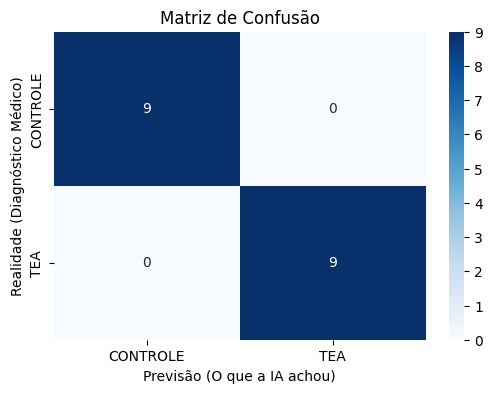

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("\n" + "="*60)
print("🧠 PROVA DE CONCEITO: TREINAMENTO DO RANDOM FOREST")
print("="*60)

# 1. CARREGAR OS DADOS
caminho_dados = '/workspaces/EyeTracking_analysis/reports/dataset_features_ml.csv'
df = pd.read_csv(caminho_dados)

# 2. PREPARAÇÃO DOS DADOS (Features e Target)
# Variáveis que a IA vai usar para aprender (X)
X = df[['Pupila_Media_mm', 'OL_Olhos_ms', 'OL_Nariz_ms', 'OL_Boca_ms']]

# A resposta que a IA tem de adivinhar (y)
y = df['Grupo']

# 3. DIVISÃO DE TREINO E TESTE
# 70% para estudar (treino), 30% para a prova final (teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print(f"Volume de Treino: {len(X_train)} faces")
print(f"Volume de Teste: {len(X_test)} faces\n")

# 4. TREINAMENTO DO MODELO
# Criamos uma floresta com 100 árvores de decisão
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
modelo_rf.fit(X_train, y_train) # A IA estuda aqui

# 5. AVALIAÇÃO (A PROVA)
y_pred = modelo_rf.predict(X_test) # A IA faz a prova cega aqui

# 6. MÉTRICAS E RESULTADOS
acuracia = accuracy_score(y_test, y_pred)
print(f"🏆 Acurácia Geral do Modelo: {acuracia * 100:.2f}%\n")

print("📊 Relatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred))

# 7. O QUE A IA ACHOU MAIS IMPORTANTE? (Feature Importance)
importancias = modelo_rf.feature_importances_
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

print("\n🔍 Importância das Variáveis (O que mais pesou na decisão):")
for idx, row in features_df.iterrows():
    print(f" - {row['Feature']}: {row['Importancia']*100:.1f}%")

# Bônus: Matriz de Confusão Visual
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=modelo_rf.classes_, yticklabels=modelo_rf.classes_)
plt.title('Matriz de Confusão')
plt.ylabel('Realidade (Diagnóstico Médico)')
plt.xlabel('Previsão (O que a IA achou)')
plt.show()


INICIANDO GERAÇÃO DAS 3 VIEWS DE OURO DO EYE TRACKING
Gerando View 1: Assinatura de Atenção...
Gerando View 2: Variância Foco nos Olhos...


/tmp/ipykernel_4080/1201652958.py:35: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g1 = sns.barplot(x='AOI_Label', y='Tempo_ms', hue='Grupo', data=df_long_aoi, ci=None, ax=axes[0])


Gerando View 3: Carga Cognitiva vs. Emoção...


/tmp/ipykernel_4080/1201652958.py:61: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  g3 = sns.pointplot(x='Emocao', y='Pupila_Media_mm', hue='Grupo', data=df,



🎯 3 VIEWS CONCLUÍDAS. EXIBINDO PLOTS.


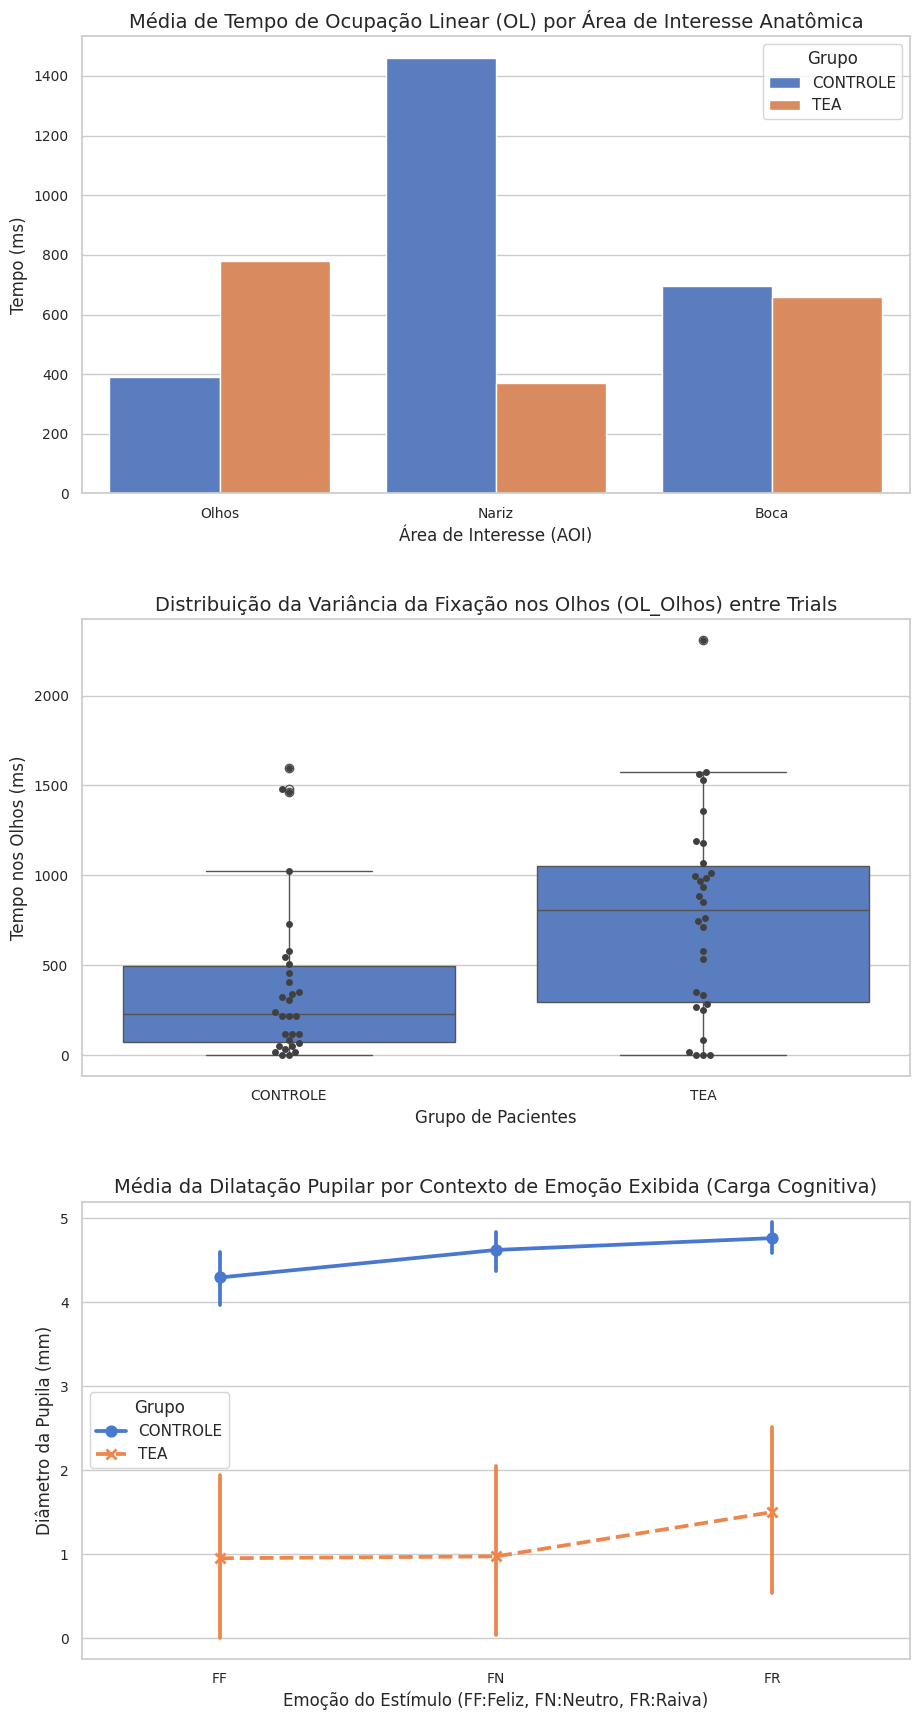

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurações de estilo para qualidade de publicação
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

print("\n" + "="*60)
print("INICIANDO GERAÇÃO DAS 3 VIEWS DE OURO DO EYE TRACKING")
print("="*60)

# 1. CARREGAR OS DADOS (Resultados da PoC)
caminho_dados = '/workspaces/EyeTracking_analysis/reports/dataset_features_ml.csv'
df = pd.read_csv(caminho_dados)

# Dicionário para legendas mais bonitas baseadas na tese
labels_aoi = {'OL_Olhos_ms': 'Olhos', 'OL_Nariz_ms': 'Nariz', 'OL_Boca_ms': 'Boca'}

# Preparamos o layout dos gráficos (3 linhas, 1 coluna)
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# ============================================================
# VIEW 1: ASSINATURA DA ALOCAÇÃO DE ATENÇÃO (Grouped Bar Chart)
# Foco: Onde eles olharam, em média.
# ============================================================
print("Gerando View 1: Assinatura de Atenção...")
# Transformamos os dados em formato longo para plotagem categórica
df_long_aoi = df.melt(id_vars=['Grupo'], value_vars=['OL_Olhos_ms', 'OL_Nariz_ms', 'OL_Boca_ms'],
                        var_name='AOI', value_name='Tempo_ms')
# Mapeamos as AOIs para os nomes corretos
df_long_aoi['AOI_Label'] = df_long_aoi['AOI'].map(labels_aoi)

g1 = sns.barplot(x='AOI_Label', y='Tempo_ms', hue='Grupo', data=df_long_aoi, ci=None, ax=axes[0])
g1.set_title('Média de Tempo de Ocupação Linear (OL) por Área de Interesse Anatômica', fontsize=14)
g1.set_ylabel('Tempo (ms)', fontsize=12)
g1.set_xlabel('Área de Interesse (AOI)', fontsize=12)
axes[0].tick_params(labelsize=10)


# ============================================================
# VIEW 2: DISTRIBUIÇÃO E VARIÂNCIA DO FOCO NOS OLHOS (Boxplot + Swarm)
# Foco: Quão consistente é o foco no olhar?
# ============================================================
print("Gerando View 2: Variância Foco nos Olhos...")
g2 = sns.boxplot(x='Grupo', y='OL_Olhos_ms', data=df, ax=axes[1])
# Adicionamos os pontos individuais (trials) para transparência dos dados
sns.swarmplot(x='Grupo', y='OL_Olhos_ms', data=df, color=".25", size=5, ax=axes[1])
g2.set_title('Distribuição da Variância da Fixação nos Olhos (OL_Olhos) entre Trials', fontsize=14)
g2.set_ylabel('Tempo nos Olhos (ms)', fontsize=12)
g2.set_xlabel('Grupo de Pacientes', fontsize=12)
axes[1].tick_params(labelsize=10)


# ============================================================
# VIEW 3: CARGA COGNITIVA POR CONTEXTO EMOCIONAL (Pointplot)
# Foco: Como a pupila reage a diferentes emoções.
# ============================================================
print("Gerando View 3: Carga Cognitiva vs. Emoção...")
g3 = sns.pointplot(x='Emocao', y='Pupila_Media_mm', hue='Grupo', data=df, 
                   join=True, markers=["o", "x"], linestyles=["-", "--"], ax=axes[2])
g3.set_title('Média da Dilatação Pupilar por Contexto de Emoção Exibida (Carga Cognitiva)', fontsize=14)
g3.set_ylabel('Diâmetro da Pupila (mm)', fontsize=12)
g3.set_xlabel('Emoção do Estímulo (FF:Feliz, FN:Neutro, FR:Raiva)', fontsize=12)
axes[2].tick_params(labelsize=10)

plt.tight_layout(pad=3.0)
print("\n" + "="*60)
print("🎯 3 VIEWS CONCLUÍDAS. EXIBINDO PLOTS.")
print("="*60)
plt.show()


🧠 PROVA DE CONCEITO: MACHINE LEARNING SEPARADO POR EMOÇÃO

--- Treinando Modelo para Face: Feliz (FF) ---
Volume de Treino: 14 faces | Volume de Teste: 6 faces
🏆 Acurácia: 83.33%
🔍 Top Variável para diferenciar TEA/Controle em faces Feliz: Pupila_Media_mm (61.2%)

--- Treinando Modelo para Face: Neutra (FN) ---
Volume de Treino: 14 faces | Volume de Teste: 6 faces
🏆 Acurácia: 100.00%
🔍 Top Variável para diferenciar TEA/Controle em faces Neutra: Pupila_Media_mm (54.3%)

--- Treinando Modelo para Face: Raiva (FR) ---
Volume de Treino: 14 faces | Volume de Teste: 6 faces
🏆 Acurácia: 100.00%
🔍 Top Variável para diferenciar TEA/Controle em faces Raiva: Pupila_Media_mm (48.7%)

GERANDO VISUALIZAÇÕES COMPARATIVAS POR EMOÇÃO...


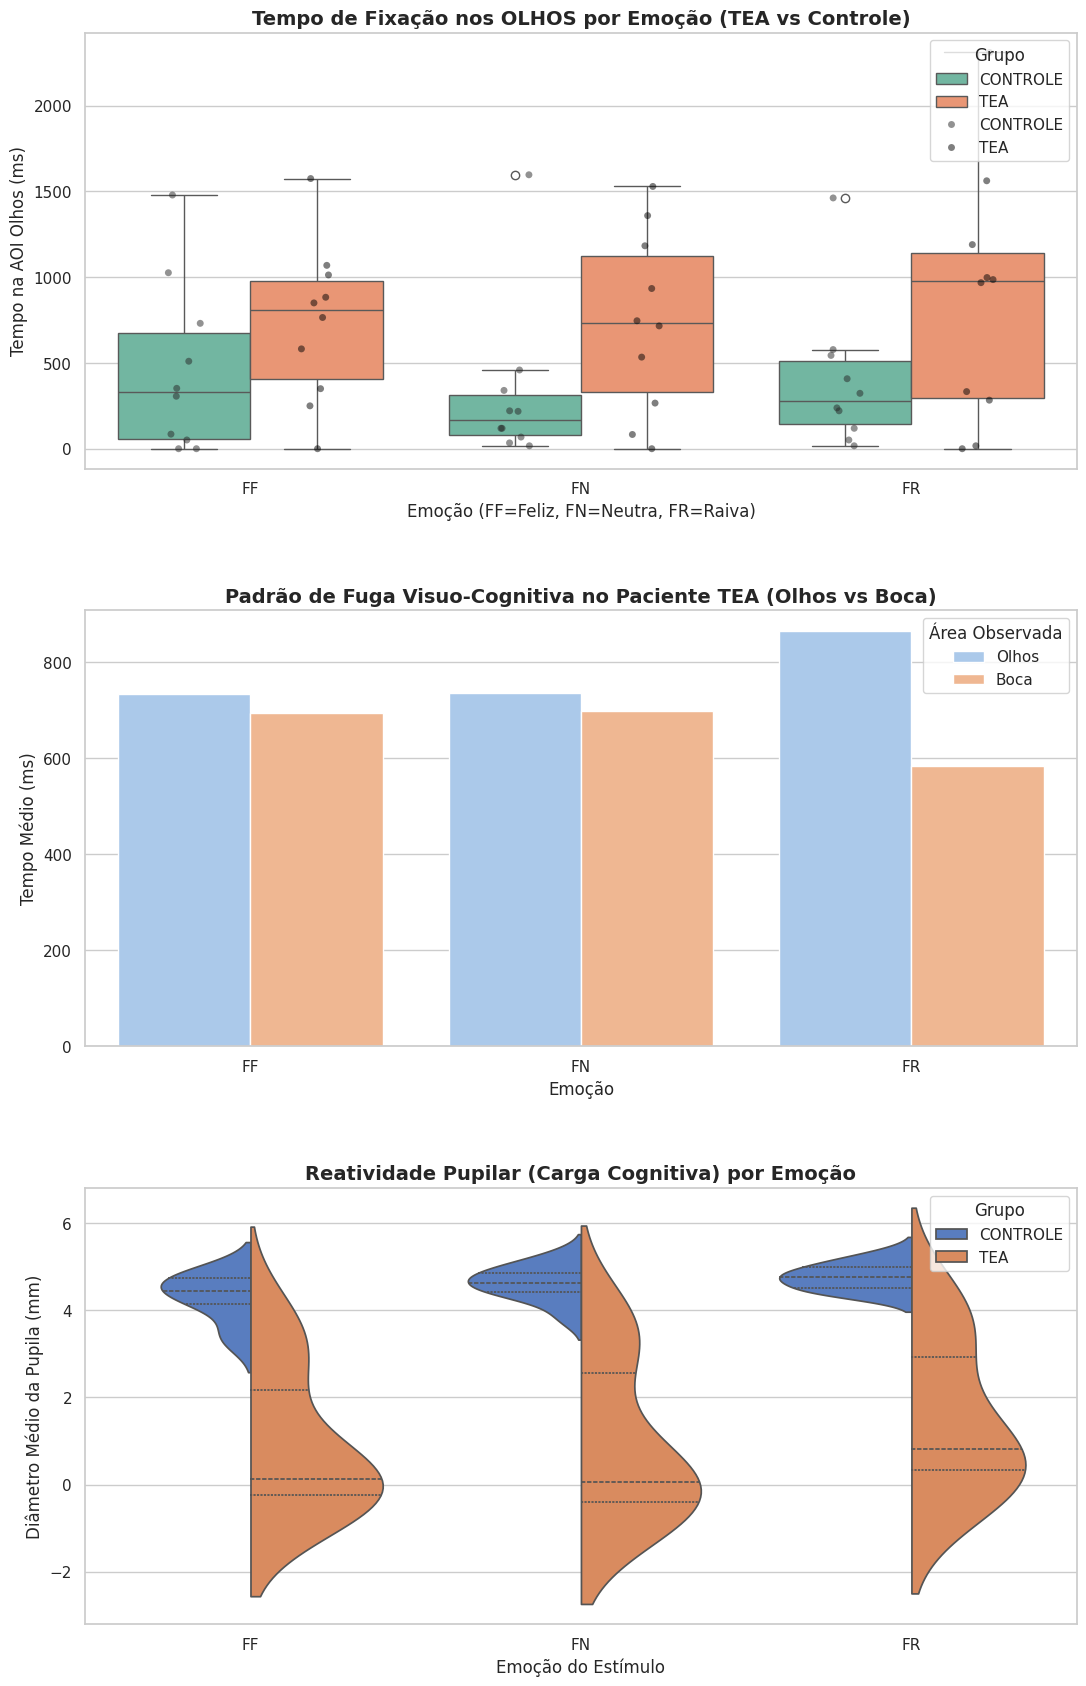

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings

# Silenciar avisos de amostra pequena
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("🧠 PROVA DE CONCEITO: MACHINE LEARNING SEPARADO POR EMOÇÃO")
print("="*80)

# 1. CARREGAR OS DADOS
caminho_dados = '/workspaces/EyeTracking_analysis/reports/dataset_features_ml.csv'
try:
    df = pd.read_csv(caminho_dados)
except FileNotFoundError:
    print("Ficheiro não encontrado. Certifique-se de que rodou o código de extração anterior.")
    raise

emocoes = ['FF', 'FN', 'FR']
nomes_emocoes = {'FF': 'Feliz', 'FN': 'Neutra', 'FR': 'Raiva'}

# 2. TREINAMENTO DE 3 MODELOS INDEPENDENTES
for emo in emocoes:
    print(f"\n--- Treinando Modelo para Face: {nomes_emocoes[emo]} ({emo}) ---")
    
    # Filtramos o dataset apenas para a emoção atual
    df_emo = df[df['Emocao'] == emo]
    
    if len(df_emo) < 10:
        print(f"Dados insuficientes para {emo}.")
        continue
        
    X = df_emo[['Pupila_Media_mm', 'OL_Olhos_ms', 'OL_Nariz_ms', 'OL_Boca_ms']]
    y = df_emo['Grupo']
    
    # Divisão de Treino e Teste (Atenção: Amostra minúscula de 20 linhas)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
    
    modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=3)
    modelo_rf.fit(X_train, y_train)
    
    y_pred = modelo_rf.predict(X_test)
    acuracia = accuracy_score(y_test, y_pred)
    
    print(f"Volume de Treino: {len(X_train)} faces | Volume de Teste: {len(X_test)} faces")
    print(f"🏆 Acurácia: {acuracia * 100:.2f}%")
    
    # Importância das Variáveis
    importancias = modelo_rf.feature_importances_
    features_df = pd.DataFrame({'Feature': X.columns, 'Importancia': importancias}).sort_values(by='Importancia', ascending=False)
    
    print(f"🔍 Top Variável para diferenciar TEA/Controle em faces {nomes_emocoes[emo]}: {features_df.iloc[0]['Feature']} ({features_df.iloc[0]['Importancia']*100:.1f}%)")

# ============================================================
# GERAÇÃO DAS 3 VIEWS FOCADAS EM EMOÇÃO
# ============================================================
print("\n" + "="*80)
print("GERANDO VISUALIZAÇÕES COMPARATIVAS POR EMOÇÃO...")
print("="*80)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# VIEW 1: FOCO NOS OLHOS SEPARADO POR EMOÇÃO (Boxplot)
# O objetivo aqui é ver se o TEA desvia o olhar dos olhos mais na face de Raiva ou na Feliz
sns.boxplot(x='Emocao', y='OL_Olhos_ms', hue='Grupo', data=df, ax=axes[0], palette="Set2")
sns.stripplot(x='Emocao', y='OL_Olhos_ms', hue='Grupo', data=df, dodge=True, color='black', alpha=0.5, ax=axes[0])
axes[0].set_title('Tempo de Fixação nos OLHOS por Emoção (TEA vs Controle)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Tempo na AOI Olhos (ms)', fontsize=12)
axes[0].set_xlabel('Emoção (FF=Feliz, FN=Neutra, FR=Raiva)', fontsize=12)
axes[0].legend(title='Grupo', loc='upper right')

# VIEW 2: MAPA DE ATENÇÃO (OLHOS VS BOCA) POR EMOÇÃO
# O objetivo é verificar a tese de que o TEA procura a boca como fuga cognitiva
df_melt = df.melt(id_vars=['Grupo', 'Emocao'], value_vars=['OL_Olhos_ms', 'OL_Boca_ms'], var_name='AOI', value_name='Tempo_ms')
df_melt['AOI'] = df_melt['AOI'].replace({'OL_Olhos_ms': 'Olhos', 'OL_Boca_ms': 'Boca'})

sns.barplot(x='Emocao', y='Tempo_ms', hue='AOI', data=df_melt[df_melt['Grupo']=='TEA'], ax=axes[1], ci=None, palette="pastel")
axes[1].set_title('Padrão de Fuga Visuo-Cognitiva no Paciente TEA (Olhos vs Boca)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Tempo Médio (ms)', fontsize=12)
axes[1].set_xlabel('Emoção', fontsize=12)
axes[1].legend(title='Área Observada', loc='upper right')

# VIEW 3: CARGA COGNITIVA E DILATAÇÃO PUPILAR
# Medimos a ativação do sistema nervoso simpático face a diferentes estímulos
sns.violinplot(x='Emocao', y='Pupila_Media_mm', hue='Grupo', data=df, split=True, inner="quart", ax=axes[2], palette="muted")
axes[2].set_title('Reatividade Pupilar (Carga Cognitiva) por Emoção', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Diâmetro Médio da Pupila (mm)', fontsize=12)
axes[2].set_xlabel('Emoção do Estímulo', fontsize=12)
axes[2].legend(title='Grupo', loc='upper right')

plt.tight_layout(pad=4.0)
plt.show()

OUTRA ABORDAGEM


RADAR DE SINCRONIZAÇÃO: BUSCA PELO PADRÃO DE 30 FACES


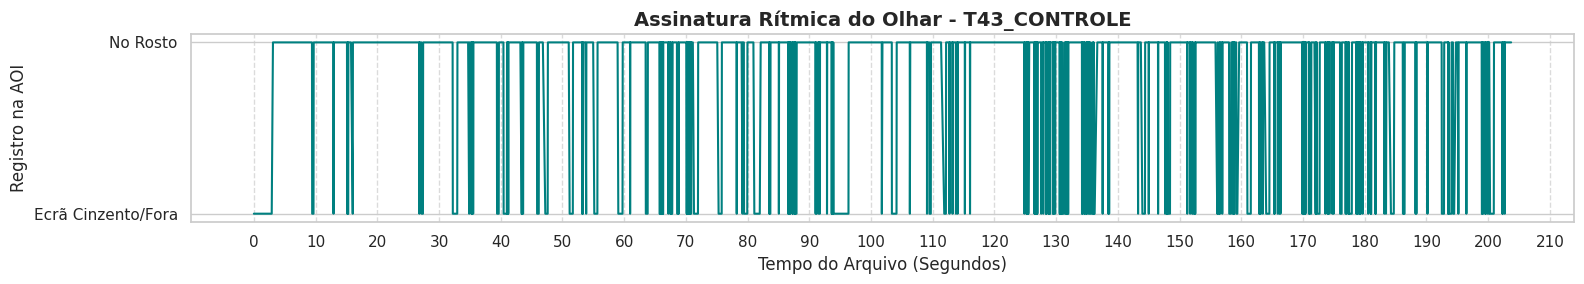

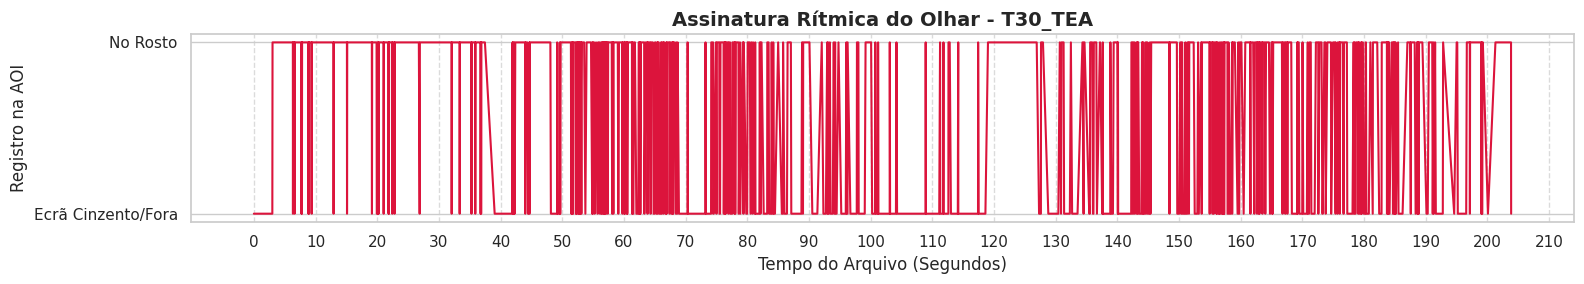

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*60)
print("RADAR DE SINCRONIZAÇÃO: BUSCA PELO PADRÃO DE 30 FACES")
print("="*60)

DADOS_EYE_TRACKER = {
    'T43_CONTROLE': '/workspaces/EyeTracking_analysis/data/csv/T43_CONTROLE_convertido.csv', 
    'T30_TEA': '/workspaces/EyeTracking_analysis/data/csv/T30 TEA GRAVE.csv'
}

for paciente, caminho in DADOS_EYE_TRACKER.items():
    df_raw = pd.read_csv(caminho)
    
    # Criamos uma coluna binária: 1 se o paciente olhou para o ecrã/rosto, 0 se não.
    df_raw['AOI_Num'] = pd.to_numeric(df_raw['AOI'], errors='coerce').fillna(0)
    df_raw['Olhando_Rosto'] = np.where(df_raw['AOI_Num'] > 0, 1, 0)
    
    plt.figure(figsize=(16, 3))
    # Plotamos o tempo convertido para segundos para ser mais fácil de ler
    plt.plot(df_raw['Time (ms)'] / 1000, df_raw['Olhando_Rosto'], color='teal' if 'CONTROLE' in paciente else 'crimson')
    
    plt.title(f'Assinatura Rítmica do Olhar - {paciente}', fontsize=14, fontweight='bold')
    plt.xlabel('Tempo do Arquivo (Segundos)', fontsize=12)
    plt.ylabel('Registro na AOI', fontsize=12)
    plt.yticks([0, 1], ['Ecrã Cinzento/Fora', 'No Rosto'])
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Mostra os ticks de 10 em 10 segundos para precisão
    plt.xticks(np.arange(0, (df_raw['Time (ms)'].max() / 1000) + 10, 10))
    
    plt.tight_layout()
    plt.show()

In [16]:
import pandas as pd
import numpy as np
import os

print("\n" + "="*60)
print("EXTRAÇÃO FINAL: ÂNCORAS VISUAIS + JANELA DE 3 SEGUNDOS")
print("="*60)

# 1. CAMINHOS
ARQUIVO_TEMPOS = '/workspaces/EyeTracking_analysis/reports/tabela_tempos_estimulos_faces_limpa.csv'

DADOS_EYE_TRACKER = {
    'T43_CONTROLE': '/workspaces/EyeTracking_analysis/data/csv/T43_CONTROLE_convertido.csv', 
    'T30_TEA': '/workspaces/EyeTracking_analysis/data/csv/T30 TEA GRAVE.csv'
}

# AS ÂNCORAS DE OURO (Extraídas da visualização gráfica do Eye Tracker)
ANCORAS_MANUAIS_MS = {
    'T43_CONTROLE': 3077, 
    'T30_TEA': 3011       
}

df_tempos = pd.read_csv(ARQUIVO_TEMPOS)

def extrair_features(paciente_id, caminho_et, grupo):
    print(f"\n--- Processando: {paciente_id} ({grupo}) ---")
    
    if not os.path.exists(caminho_et):
        print(f"❌ Arquivo {caminho_et} não encontrado.")
        return pd.DataFrame()

    df_raw = pd.read_csv(caminho_et)
    
    id_busca = 'control_43' if '43' in paciente_id else 'TEA_G_30'
    tempos_pasc = df_tempos[df_tempos['Paciente_ID'] == id_busca].sort_values('Face_Ordem')

    # Ponto Zero do EEG
    onset_primeira_face_eeg = tempos_pasc.iloc[0]['Onset_Segundos']
    
    # Ponto Zero do Eye Tracker (A Âncora Visual Manual)
    ancora_tempo_et = ANCORAS_MANUAIS_MS[paciente_id]
    
    features_paciente = []
    df_raw['AOI_Num'] = pd.to_numeric(df_raw['AOI'], errors='coerce').fillna(0).astype(int)
    
    for _, row in tempos_pasc.iterrows():
        face_idx = row['Face_Ordem']
        emocao = row['Estimulo']
        
        # CÁLCULO RELATIVO
        tempo_decorrido = row['Onset_Segundos'] - onset_primeira_face_eeg
        
        # O CORTE DE OURO
        inicio = ancora_tempo_et + (tempo_decorrido * 1000)
        fim = inicio + 3000  # Janela rígida de 3000ms
        
        fatia = df_raw[(df_raw['Time (ms)'] >= inicio) & (df_raw['Time (ms)'] <= fim)]
        
        if fatia.empty:
            print(f"  ⚠️ Face {face_idx:02d} ({emocao}) - Sem dados. Início procurado: {inicio}ms")
            continue
            
        # EXTRAÇÃO DO PARÂMETRO 'OL' (Conforme Tabela 2 da Tese)
        pupila_l = pd.to_numeric(fatia['Pupil Diameter Left (mm)'], errors='coerce').mean()
        pupila_r = pd.to_numeric(fatia['Pupil Diameter Right (mm)'], errors='coerce').mean()
        pupila_final = np.nanmean([pupila_l, pupila_r])

        ol_olhos = fatia[fatia['AOI_Num'].isin([1, 4])]['Timegap (ms)'].sum()
        ol_nariz = fatia[fatia['AOI_Num'].isin([2, 5])]['Timegap (ms)'].sum()
        ol_boca  = fatia[fatia['AOI_Num'].isin([3, 6])]['Timegap (ms)'].sum()
        
        features_paciente.append({
            'ID': paciente_id,
            'Grupo': grupo,
            'Face_N': face_idx,
            'Emocao': emocao,
            'Pupila_Media_mm': round(pupila_final, 3) if not np.isnan(pupila_final) else 0.0,
            'OL_Olhos_ms': ol_olhos,
            'OL_Nariz_ms': ol_nariz,
            'OL_Boca_ms': ol_boca,
            'Tempo_Total_Gravado_ms': fatia['Timegap (ms)'].sum()
        })

    return pd.DataFrame(features_paciente)

# 3. EXECUÇÃO
features_t43 = extrair_features('T43_CONTROLE', DADOS_EYE_TRACKER['T43_CONTROLE'], 'CONTROLE')
features_t30 = extrair_features('T30_TEA', DADOS_EYE_TRACKER['T30_TEA'], 'TEA')

dataset_final = pd.concat([features_t43, features_t30], ignore_index=True)
caminho_dataset_ml = '/workspaces/EyeTracking_analysis/reports/dataset_features_ml.csv'
dataset_final.to_csv(caminho_dataset_ml, index=False)

print("\n" + "="*60)
print("🎯 DATASET CONSTRUÍDO COM SUCESSO!")
print(f"Total de faces prontas: {len(dataset_final)}")
print("="*60)
display(dataset_final.head(10))


EXTRAÇÃO FINAL: ÂNCORAS VISUAIS + JANELA DE 3 SEGUNDOS

--- Processando: T43_CONTROLE (CONTROLE) ---

--- Processando: T30_TEA (TEA) ---

🎯 DATASET CONSTRUÍDO COM SUCESSO!
Total de faces prontas: 60


,ID,Grupo,Face_N,Emocao,Pupila_Media_mm,OL_Olhos_ms,OL_Nariz_ms,OL_Boca_ms,Tempo_Total_Gravado_ms
0,T43_CONTROLE,CONTROLE,1,FF,4.150,1298,1496,418,3212
1,T43_CONTROLE,CONTROLE,2,FN,4.638,2191,527,83,3056
2,T43_CONTROLE,CONTROLE,3,FR,4.964,2074,918,68,3077
3,T43_CONTROLE,CONTROLE,4,FF,4.681,204,1955,425,3054
4,T43_CONTROLE,CONTROLE,5,FN,4.773,204,2550,323,3077
5,T43_CONTROLE,CONTROLE,6,FR,5.096,170,2040,833,3043
6,T43_CONTROLE,CONTROLE,7,FF,4.348,422,1989,405,3071
7,T43_CONTROLE,CONTROLE,8,FN,4.736,170,2091,17,3043
8,T43_CONTROLE,CONTROLE,9,FR,4.757,289,1326,1392,3058
9,T43_CONTROLE,CONTROLE,10,FF,4.878,986,1003,102,3060



🧠 PROVA DE CONCEITO: MACHINE LEARNING E VIEWS POR EMOÇÃO

--- Treinando Modelo para Face: Feliz (FF) ---
Volume de Treino: 14 faces | Teste: 6 faces
🏆 Acurácia: 83.33%
🔍 Principal Variável Preditiva: Pupila_Media_mm (50.5%)

--- Treinando Modelo para Face: Neutra (FN) ---
Volume de Treino: 14 faces | Teste: 6 faces
🏆 Acurácia: 83.33%
🔍 Principal Variável Preditiva: Pupila_Media_mm (60.2%)

--- Treinando Modelo para Face: Raiva (FR) ---
Volume de Treino: 14 faces | Teste: 6 faces
🏆 Acurácia: 66.67%
🔍 Principal Variável Preditiva: Pupila_Media_mm (49.6%)


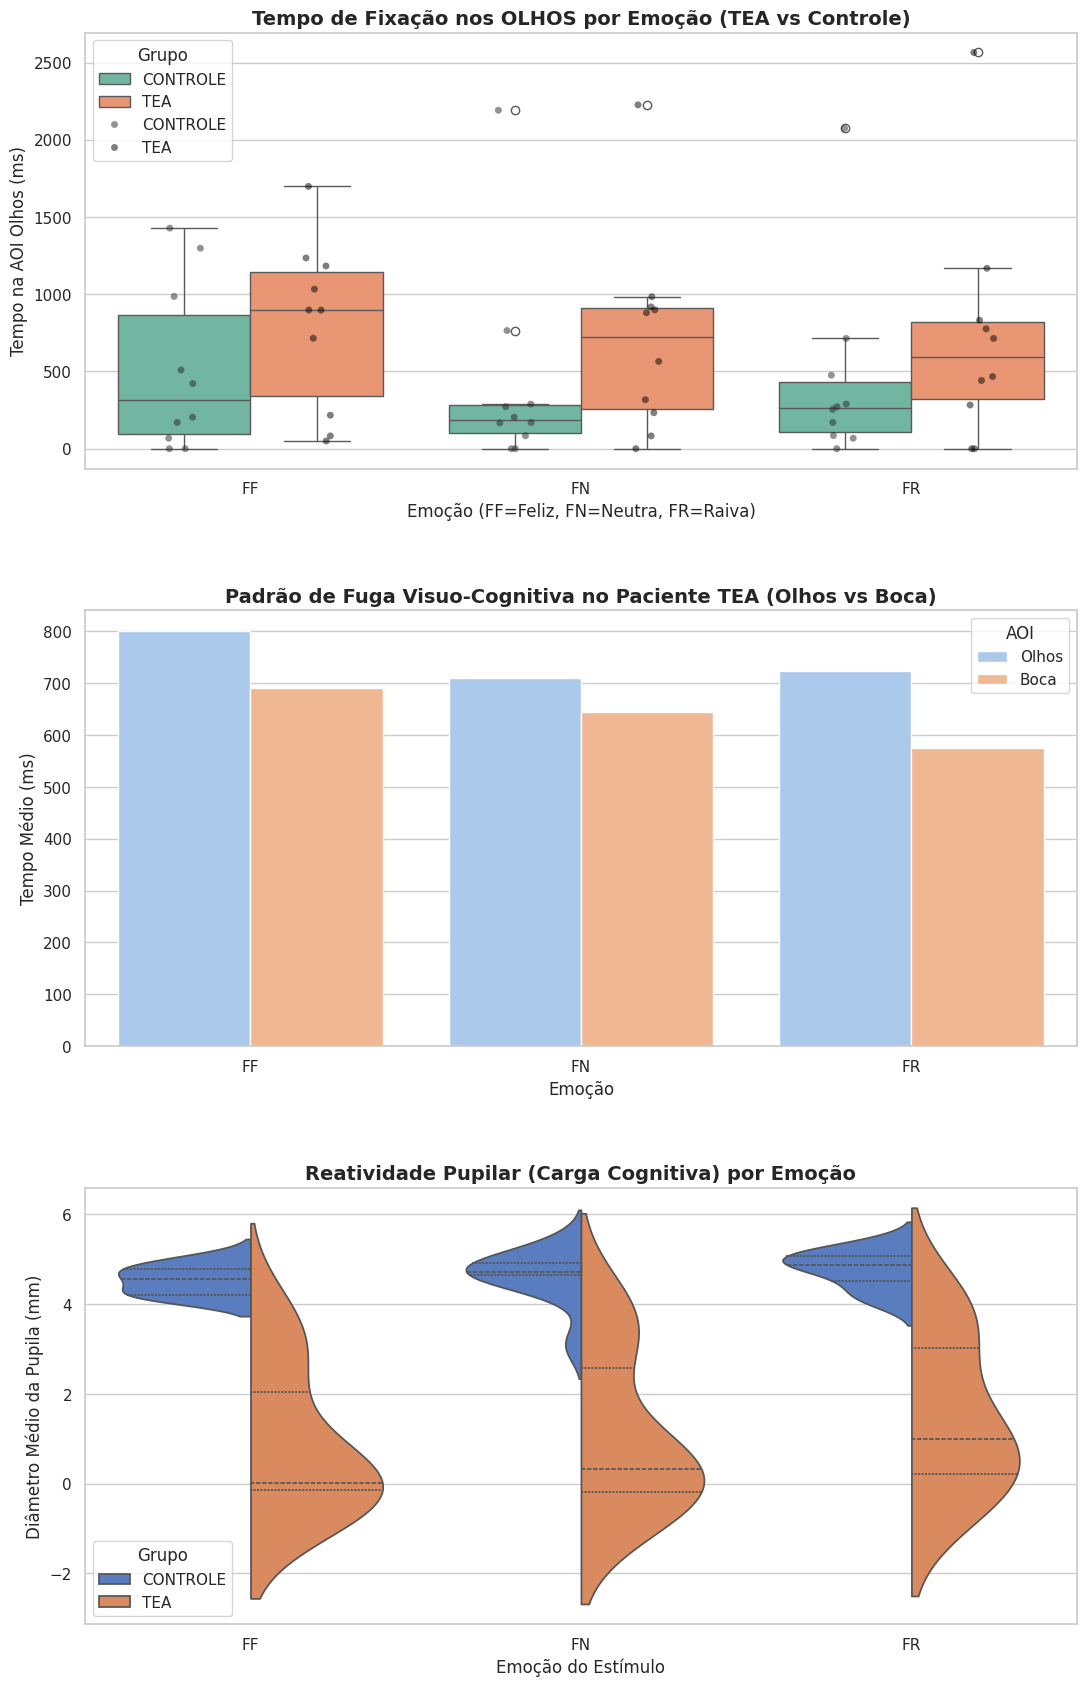

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings

warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("🧠 PROVA DE CONCEITO: MACHINE LEARNING E VIEWS POR EMOÇÃO")
print("="*80)

# 1. CARREGAR OS DADOS VALIDADOS
caminho_dados = '/workspaces/EyeTracking_analysis/reports/dataset_features_ml.csv'
df = pd.read_csv(caminho_dados)

emocoes = ['FF', 'FN', 'FR']
nomes_emocoes = {'FF': 'Feliz', 'FN': 'Neutra', 'FR': 'Raiva'}

# 2. TREINAMENTO DOS MODELOS
for emo in emocoes:
    print(f"\n--- Treinando Modelo para Face: {nomes_emocoes[emo]} ({emo}) ---")
    
    df_emo = df[df['Emocao'] == emo]
    if len(df_emo) < 10:
        continue
        
    X = df_emo[['Pupila_Media_mm', 'OL_Olhos_ms', 'OL_Nariz_ms', 'OL_Boca_ms']]
    y = df_emo['Grupo']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
    
    modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=3)
    modelo_rf.fit(X_train, y_train)
    
    y_pred = modelo_rf.predict(X_test)
    acuracia = accuracy_score(y_test, y_pred)
    
    print(f"Volume de Treino: {len(X_train)} faces | Teste: {len(X_test)} faces")
    print(f"🏆 Acurácia: {acuracia * 100:.2f}%")
    
    importancias = modelo_rf.feature_importances_
    features_df = pd.DataFrame({'Feature': X.columns, 'Importancia': importancias}).sort_values(by='Importancia', ascending=False)
    print(f"🔍 Principal Variável Preditiva: {features_df.iloc[0]['Feature']} ({features_df.iloc[0]['Importancia']*100:.1f}%)")

# 3. GERAÇÃO DAS VISUALIZAÇÕES
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# VIEW 1: FOCO NOS OLHOS SEPARADO POR EMOÇÃO
sns.boxplot(x='Emocao', y='OL_Olhos_ms', hue='Grupo', data=df, ax=axes[0], palette="Set2")
sns.stripplot(x='Emocao', y='OL_Olhos_ms', hue='Grupo', data=df, dodge=True, color='black', alpha=0.5, ax=axes[0])
axes[0].set_title('Tempo de Fixação nos OLHOS por Emoção (TEA vs Controle)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Tempo na AOI Olhos (ms)', fontsize=12)
axes[0].set_xlabel('Emoção (FF=Feliz, FN=Neutra, FR=Raiva)', fontsize=12)

# VIEW 2: MAPA DE ATENÇÃO (OLHOS VS BOCA) NO TEA
df_melt = df.melt(id_vars=['Grupo', 'Emocao'], value_vars=['OL_Olhos_ms', 'OL_Boca_ms'], var_name='AOI', value_name='Tempo_ms')
df_melt['AOI'] = df_melt['AOI'].replace({'OL_Olhos_ms': 'Olhos', 'OL_Boca_ms': 'Boca'})
sns.barplot(x='Emocao', y='Tempo_ms', hue='AOI', data=df_melt[df_melt['Grupo']=='TEA'], ax=axes[1], ci=None, palette="pastel")
axes[1].set_title('Padrão de Fuga Visuo-Cognitiva no Paciente TEA (Olhos vs Boca)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Tempo Médio (ms)', fontsize=12)
axes[1].set_xlabel('Emoção', fontsize=12)

# VIEW 3: DILATAÇÃO PUPILAR POR EMOÇÃO
sns.violinplot(x='Emocao', y='Pupila_Media_mm', hue='Grupo', data=df, split=True, inner="quart", ax=axes[2], palette="muted")
axes[2].set_title('Reatividade Pupilar (Carga Cognitiva) por Emoção', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Diâmetro Médio da Pupila (mm)', fontsize=12)
axes[2].set_xlabel('Emoção do Estímulo', fontsize=12)

plt.tight_layout(pad=4.0)
plt.show()

Agora - fazer tentativa com 60 faces 

In [4]:
import pandas as pd
import os
import glob

print("\n" + "="*80)
print("INSPETOR DE NOMENCLATURA E ESTRUTURA - 42 PARTICIPANTES")
print("="*80)

PASTA_DADOS = '/workspaces/EyeTracking_analysis/data/raw/'
arquivos_xlsx = glob.glob(os.path.join(PASTA_DADOS, '*.xlsx'))

if not arquivos_xlsx:
    print(f"❌ Nenhum arquivo .xlsx encontrado na pasta {PASTA_DADOS}")
else:
    print(f"Detectados {len(arquivos_xlsx)} arquivos. Iniciando varredura...\n")
    
    for i, caminho in enumerate(arquivos_xlsx, 1):
        nome_arquivo = os.path.basename(caminho).replace('.xlsx', '')
        print(f"\n[Arquivo {i:02d}/42] {nome_arquivo}")
        print("-" * 50)
        
        try:
            # Lemos apenas as primeiras 200 linhas para coletar a estrutura rapidamente
            df_sample = pd.read_excel(caminho, nrows=200)
            
            # 1. Mapeamento de Colunas
            colunas = list(df_sample.columns)
            print(f" 📂 Colunas encontradas: {colunas[:6]}... (Total: {len(colunas)})")
            
            # 2. Busca inteligente pela coluna de AOI
            coluna_aoi_encontrada = [col for col in colunas if 'aoi' in col.lower() or 'interest' in col.lower()]
            
            if coluna_aoi_encontrada:
                col_aoi = coluna_aoi_encontrada[0]
                print(f" 🎯 Coluna identificada para AOI: '{col_aoi}'")
                
                # Coletar valores únicos (lemos o arquivo completo de forma otimizada para ver os valores de AOI)
                df_completo_aoi = pd.read_excel(caminho, usecols=[col_aoi])
                valores_unicos = df_completo_aoi[col_aoi].dropna().unique()
                print(f" 🔍 Amostra de valores gravados na AOI: {list(valores_unicos[:10])}")
            else:
                print(" ⚠️ Alerta: Nenhuma coluna parecida com 'AOI' ou 'Interest' foi detectada.")
                
            # 3. Busca inteligente pela coluna de Tempo
            coluna_tempo_encontrada = [col for col in colunas if 'time' in col.lower() or 'tempo' in col.lower()]
            if coluna_tempo_encontrada:
                print(f" ⏱️ Coluna de tempo identificada: '{coluna_tempo_encontrada[0]}'")
            else:
                print(" ⚠️ Alerta: Nenhuma coluna de tempo detectada.")
                
        except Exception as e:
            msg_erro = str(e)
            if "format cannot be determined" in msg_erro:
                print(" ℹ️ Formato de Excel inválido. Tentando ler como arquivo de texto/CSV...")
                try:
                    # Teste rápido para ver se o arquivo é na verdade um CSV/TSV disfarçado de Excel
                    df_tsv = pd.read_csv(caminho, sep='\t', nrows=5)
                    print(f" 💡 Descoberto! O arquivo é um texto separado por TAB. Colunas: {list(df_tsv.columns[:5])}")
                except:
                    print(f" ❌ Erro crítico de leitura: {msg_erro[:60]}")
            else:
                print(f" ❌ Erro ao abrir arquivo: {msg_erro[:80]}")
                
    print("\n" + "="*80)
    print("FIM DA INSPEÇÃO. PRONTO PARA ANÁLISE DOS PADRÕES.")
    print("="*80)


INSPETOR DE NOMENCLATURA E ESTRUTURA - 42 PARTICIPANTES
Detectados 41 arquivos. Iniciando varredura...


[Arquivo 01/42] T47 CONTROLE
--------------------------------------------------
 📂 Colunas encontradas: ['No.', 'Name', 'Time (ms)', 'Timegap (ms)', 'Duration', 'Gaze X']... (Total: 19)
 🎯 Coluna identificada para AOI: 'AOI'
 🔍 Amostra de valores gravados na AOI: ['-']
 ⏱️ Coluna de tempo identificada: 'Time (ms)'

[Arquivo 02/42] T49 CONTROLE
--------------------------------------------------
 📂 Colunas encontradas: ['No.', 'Name', 'Time (ms)', 'Timegap (ms)', 'Duration', 'Gaze X']... (Total: 19)
 🎯 Coluna identificada para AOI: 'AOI'
 🔍 Amostra de valores gravados na AOI: ['-']
 ⏱️ Coluna de tempo identificada: 'Time (ms)'

[Arquivo 03/42] T40 TEA GRAVE
--------------------------------------------------
 📂 Colunas encontradas: ['No.', 'Name', 'Time (ms)', 'Timegap (ms)', 'Duration', 'Gaze X']... (Total: 19)
 🎯 Coluna identificada para AOI: 'AOI'
 🔍 Amostra de valores gravados na 

In [1]:
import pandas as pd

print("\n" + "="*70)
print("ENGENHARIA REVERSA: EXTRAINDO BOUNDING BOXES (MOLDE DE AOIs)")
print("="*70)

# Usaremos o T43 como nosso "Espelho Geométrico"
caminho_espelho = '/workspaces/EyeTracking_analysis/data/raw/T43 CONTROLE.xlsx'

print(f"Lendo o arquivo espelho: T43 CONTROLE...")
try:
    df = pd.read_excel(caminho_espelho, usecols=['Time (ms)', 'Gaze X', 'Gaze Y', 'AOI'])
    
    # Filtrar apenas as linhas onde houve fixação válida em uma AOI
    df['AOI_Num'] = pd.to_numeric(df['AOI'], errors='coerce')
    df_validos = df.dropna(subset=['AOI_Num', 'Gaze X', 'Gaze Y'])
    
    # Criar um dicionário para guardar as coordenadas de cada caixa
    bounding_boxes = {}
    
    # As AOIs principais da tese (conforme Tabela 2 e imagem)
    # Supondo que 1 e 4 = Olhos, 2 e 5 = Nariz, 3 e 6 = Boca
    aois_alvo = [1, 2, 3, 4, 5, 6] 
    
    print("\n🔍 Coordenadas Cartesianas Extraídas (em Pixels):")
    for aoi in aois_alvo:
        dados_aoi = df_validos[df_validos['AOI_Num'] == aoi]
        
        if not dados_aoi.empty:
            x_min = dados_aoi['Gaze X'].min()
            x_max = dados_aoi['Gaze X'].max()
            y_min = dados_aoi['Gaze Y'].min()
            y_max = dados_aoi['Gaze Y'].max()
            
            bounding_boxes[aoi] = {'X_min': x_min, 'X_max': x_max, 'Y_min': y_min, 'Y_max': y_max}
            
            print(f" - AOI {aoi:02d}: X[{x_min:.1f} a {x_max:.1f}] | Y[{y_min:.1f} a {y_max:.1f}]")
        else:
            print(f" - AOI {aoi:02d}: Sem dados suficientes para mapear.")

    print("\n" + "="*70)
    print("MOLDE CRIADO COM SUCESSO! PRONTO PARA RESGATAR OS OUTROS ARQUIVOS.")
    print("="*70)

except Exception as e:
    print(f"❌ Erro ao extrair coordenadas: {e}")


ENGENHARIA REVERSA: EXTRAINDO BOUNDING BOXES (MOLDE DE AOIs)
Lendo o arquivo espelho: T43 CONTROLE...

🔍 Coordenadas Cartesianas Extraídas (em Pixels):
 - AOI 01: X[315.0 a 729.0] | Y[133.0 a 259.0]
 - AOI 02: X[185.0 a 792.0] | Y[365.0 a 417.0]
 - AOI 03: X[1.0 a 1023.0] | Y[413.0 a 766.0]
 - AOI 04: X[416.0 a 612.0] | Y[288.0 a 364.0]
 - AOI 05: X[484.0 a 569.0] | Y[417.0 a 421.0]
 - AOI 06: X[443.0 a 448.0] | Y[411.0 a 412.0]

MOLDE CRIADO COM SUCESSO! PRONTO PARA RESGATAR OS OUTROS ARQUIVOS.


In [3]:
import pandas as pd
import os
import glob
import numpy as np

print("\n" + "="*80)
print("OPERAÇÃO DE RESGATE: RECONSTRUÇÃO GEOMÉTRICA DE AOIs")
print("="*80)

PASTA_ORIGEM = '/workspaces/EyeTracking_analysis/data/raw/'
PASTA_DESTINO = '/workspaces/EyeTracking_analysis/data/csv_limpos/'

# Criar a pasta de destino se não existir
os.makedirs(PASTA_DESTINO, exist_ok=True)

arquivos_xlsx = glob.glob(os.path.join(PASTA_ORIGEM, '*.xlsx'))

# 1. O MAPA CARTOGRÁFICO (As suas coordenadas exatas)
def mapear_coordenadas_para_aoi(x, y):
    if pd.isna(x) or pd.isna(y):
        return 0
        
    # Testamos os limites geométricos extraídos do T43
    # A ordem testa primeiro as áreas menores/mais específicas
    if 443.0 <= x <= 448.0 and 411.0 <= y <= 412.0: return 6
    if 484.0 <= x <= 569.0 and 417.0 <= y <= 421.0: return 5
    if 416.0 <= x <= 612.0 and 288.0 <= y <= 364.0: return 4
    if 315.0 <= x <= 729.0 and 133.0 <= y <= 259.0: return 1
    if 185.0 <= x <= 792.0 and 365.0 <= y <= 417.0: return 2
    if 1.0 <= x <= 1023.0 and 413.0 <= y <= 766.0: return 3
    
    return 0 # Olhou para fora das caixas de interesse

resultados_resgate = []

for caminho in arquivos_xlsx:
    nome_arquivo = os.path.basename(caminho).replace('.xlsx', '')
    print(f"Resgatando paciente: {nome_arquivo}...")
    
    try:
        # Lemos apenas as colunas necessárias para processamento ultrarrápido
        df = pd.read_excel(caminho, usecols=['Time (ms)', 'Timegap (ms)', 'Gaze X', 'Gaze Y'])
        
        # 2. A MAGIA: Criamos a nova coluna aplicando a função linha por linha
        # Usamos vetorização do numpy para ser muito mais rápido do que um loop for
        df['AOI'] = np.vectorize(mapear_coordenadas_para_aoi)(df['Gaze X'], df['Gaze Y'])
        
        # Guardamos como CSV para não sofrermos mais com a lentidão do Excel
        caminho_salvamento = os.path.join(PASTA_DESTINO, f"{nome_arquivo}.csv")
        df.to_csv(caminho_salvamento, index=False)
        
        # Contamos quantas fixações em rostos conseguimos recuperar
        fixacoes_recuperadas = (df['AOI'] > 0).sum()
        
        resultados_resgate.append({
            'Paciente': nome_arquivo,
            'Status': '✅ Resgatado e Limpo',
            'Fixações Válidas': fixacoes_recuperadas
        })
        
    except Exception as e:
        resultados_resgate.append({
            'Paciente': nome_arquivo,
            'Status': f'❌ Erro: {str(e)[:40]}',
            'Fixações Válidas': 0
        })

df_relatorio = pd.DataFrame(resultados_resgate)

print("\n" + "="*80)
print("🎯 RESGATE CONCLUÍDO. RELATÓRIO DE LIMPEZA:")
print("="*80)
display(df_relatorio.head(15)) # Exibe os primeiros 15 para termos uma ideia

sucessos = len(df_relatorio[df_relatorio['Status'].str.contains('✅')])
print(f"\nResumo: {sucessos} arquivos salvos com sucesso na pasta 'data/csv_limpos/'.")


OPERAÇÃO DE RESGATE: RECONSTRUÇÃO GEOMÉTRICA DE AOIs
Resgatando paciente: T47 CONTROLE...
Resgatando paciente: T49 CONTROLE...
Resgatando paciente: T40 TEA GRAVE...
Resgatando paciente: T30 TEA GRAVE...
Resgatando paciente: T12 CONTROLE...
Resgatando paciente: T42 CONTROLE...
Resgatando paciente: T16 TEA LEVE...
Resgatando paciente: T27 TEA LEVE...
Resgatando paciente: T55 CONTROLE...
Resgatando paciente: T37 CONTROLE...
Resgatando paciente: T20 TEA MODERADO...
Resgatando paciente: T58 CONTROLE...
Resgatando paciente: T22 TEA MODERADO...
Resgatando paciente: T51 CONTROLE...
Resgatando paciente: T48 CONTROLE...
Resgatando paciente: T28 TEA GRAVE...
Resgatando paciente: T 24 TEA LEVE...
Resgatando paciente: T39 CONTROLE...
Resgatando paciente: T35 CONTROLE...
Resgatando paciente: T44 CONTROLE...
Resgatando paciente: T59 CONTROLE...
Resgatando paciente: T34 CONTROLE...
Resgatando paciente: T191 TEA MODERADO...
Resgatando paciente: T56 CONTROLE...
Resgatando paciente: T60 CONTROLE...
Resg

,Paciente,Status,Fixações Válidas
0,T47 CONTROLE,✅ Resgatado e Limpo,9607
1,T49 CONTROLE,✅ Resgatado e Limpo,11223
2,T40 TEA GRAVE,✅ Resgatado e Limpo,10531
3,T30 TEA GRAVE,✅ Resgatado e Limpo,2531
4,T12 CONTROLE,"❌ Erro: Excel file format cannot be determined,",0
5,T42 CONTROLE,✅ Resgatado e Limpo,10695
6,T16 TEA LEVE,✅ Resgatado e Limpo,1939
7,T27 TEA LEVE,✅ Resgatado e Limpo,10774
8,T55 CONTROLE,✅ Resgatado e Limpo,11156
9,T37 CONTROLE,✅ Resgatado e Limpo,10061



Resumo: 40 arquivos salvos com sucesso na pasta 'data/csv_limpos/'.


In [4]:
import pandas as pd
import numpy as np
import os
import glob

print("\n" + "="*80)
print("OPERAÇÃO DE RESGATE CIRÚRGICO: T12 CONTROLE (CSV)")
print("="*80)

PASTA_CSV_ORIGEM = '/workspaces/EyeTracking_analysis/data/csv/'
PASTA_DESTINO = '/workspaces/EyeTracking_analysis/data/csv_limpos/'

# Garantir que a pasta de destino existe
os.makedirs(PASTA_DESTINO, exist_ok=True)

# Buscar o arquivo T12 na pasta csv
arquivos_t12 = glob.glob(os.path.join(PASTA_CSV_ORIGEM, '*T12*.csv'))

# O Mapa Cartográfico Validado
def mapear_coordenadas_para_aoi(x, y):
    if pd.isna(x) or pd.isna(y): return 0
    if 443.0 <= x <= 448.0 and 411.0 <= y <= 412.0: return 6
    if 484.0 <= x <= 569.0 and 417.0 <= y <= 421.0: return 5
    if 416.0 <= x <= 612.0 and 288.0 <= y <= 364.0: return 4
    if 315.0 <= x <= 729.0 and 133.0 <= y <= 259.0: return 1
    if 185.0 <= x <= 792.0 and 365.0 <= y <= 417.0: return 2
    if 1.0 <= x <= 1023.0 and 413.0 <= y <= 766.0: return 3
    return 0 

if not arquivos_t12:
    print(f"❌ Nenhum arquivo contendo 'T12' encontrado na pasta: {PASTA_CSV_ORIGEM}")
else:
    caminho_t12 = arquivos_t12[0] # Pega o primeiro que encontrar
    nome_arquivo = os.path.basename(caminho_t12).replace('.csv', '')
    print(f"Arquivo localizado: {nome_arquivo}. Iniciando extração...\n")
    
    try:
        # Lemos o CSV. O 'sep=None' e 'engine=python' forçam o Pandas a adivinhar se é vírgula, ponto e vírgula ou TAB
        df_t12 = pd.read_csv(caminho_t12, sep=None, engine='python')
        
        # Verificar se as colunas essenciais existem
        colunas_necessarias = ['Time (ms)', 'Timegap (ms)', 'Gaze X', 'Gaze Y']
        colunas_faltantes = [col for col in colunas_necessarias if col not in df_t12.columns]
        
        if colunas_faltantes:
            print(f"❌ Erro: O CSV não possui as colunas estruturais necessárias: {colunas_faltantes}")
            print(f"Colunas disponíveis no arquivo: {list(df_t12.columns)}")
        else:
            # Aplicar a reconstrução geométrica
            df_t12['AOI'] = np.vectorize(mapear_coordenadas_para_aoi)(df_t12['Gaze X'], df_t12['Gaze Y'])
            
            # Salvar na pasta de arquivos limpos
            # Padronizamos o nome para não haver conflitos depois
            nome_salvamento = "T12_CONTROLE.csv" if "CONTROLE" in nome_arquivo.upper() else f"{nome_arquivo}_limpo.csv"
            caminho_salvamento = os.path.join(PASTA_DESTINO, nome_salvamento)
            
            # Filtramos as colunas para manter o padrão dos outros 41
            df_t12_final = df_t12[['Time (ms)', 'Timegap (ms)', 'Gaze X', 'Gaze Y', 'AOI']]
            df_t12_final.to_csv(caminho_salvamento, index=False)
            
            fixacoes_recuperadas = (df_t12_final['AOI'] > 0).sum()
            
            print(f"✅ SUCESSO! Paciente T12 resgatado e integrado à amostra.")
            print(f"📍 Salvo em: {caminho_salvamento}")
            print(f"📊 Fixações válidas mapeadas: {fixacoes_recuperadas}")
            print("\nAmostra do ficheiro limpo:")
            display(df_t12_final[df_t12_final['AOI'] > 0].head())
            
    except Exception as e:
        print(f"❌ Erro crítico ao processar o CSV: {e}")


OPERAÇÃO DE RESGATE CIRÚRGICO: T12 CONTROLE (CSV)
Arquivo localizado: T12 CONTROLE - T12. Iniciando extração...

✅ SUCESSO! Paciente T12 resgatado e integrado à amostra.
📍 Salvo em: /workspaces/EyeTracking_analysis/data/csv_limpos/T12_CONTROLE.csv
📊 Fixações válidas mapeadas: 65

Amostra do ficheiro limpo:


,Time (ms),Timegap (ms),Gaze X,Gaze Y,AOI
0,0,0,481,254,1
1,17,17,474,256,1
2,33,17,469,239,1
3,50,17,472,240,1
7,116,17,468,254,1


In [5]:
import pandas as pd
import os
import glob

print("\n" + "="*80)
print("EXTRAÇÃO FINAL: DATASET MACHINE LEARNING (N=41, 50 FACES)")
print("="*80)

PASTA_LIMPOS = '/workspaces/EyeTracking_analysis/data/csv_limpos/'
arquivos_csv = glob.glob(os.path.join(PASTA_LIMPOS, '*.csv'))

features_totais = []
pacientes_processados = 0

for caminho in arquivos_csv:
    nome_arquivo = os.path.basename(caminho).replace('.csv', '')
    
    # Excluir explicitamente o T12 caso ele ainda esteja na pasta
    if "T12" in nome_arquivo.upper():
        continue
        
    grupo = 'TEA' if 'TEA' in nome_arquivo.upper() else 'CONTROLE'
    
    try:
        df = pd.read_csv(caminho)
        
        # O Ponto Zero Dinâmico: A primeira vez que o olhar caiu dentro de uma AOI
        linhas_validas = df[df['AOI'] > 0]
        if linhas_validas.empty:
            print(f"⚠️ {nome_arquivo} ignorado (Sem dados úteis).")
            continue
            
        ponto_zero = linhas_validas['Time (ms)'].iloc[0]
        pacientes_processados += 1
        
        # Loop para extrair exatamente 50 faces
        for face_idx in range(1, 51):
            
            inicio_janela = ponto_zero + ((face_idx - 1) * 4000)
            fim_janela = inicio_janela + 3000
            
            fatia = df[(df['Time (ms)'] >= inicio_janela) & (df['Time (ms)'] <= fim_janela)]
            
            # Soma dos Tempos de Ocupação Linear (OL)
            ol_olhos = fatia[fatia['AOI'].isin([1, 4])]['Timegap (ms)'].sum()
            ol_nariz = fatia[fatia['AOI'].isin([2, 5])]['Timegap (ms)'].sum()
            ol_boca  = fatia[fatia['AOI'].isin([3, 6])]['Timegap (ms)'].sum()
            
            tempo_gravado = fatia[fatia['AOI'] > 0]['Timegap (ms)'].sum()
            
            # Cálculo do Biomarcador de Fuga Visual (Evitando números negativos por flutuação de frame)
            tempo_ausente = max(0, 3000 - tempo_gravado) 
            
            features_totais.append({
                'ID': nome_arquivo,
                'Grupo': grupo,
                'Face_N': face_idx,
                'Categoria': 'Humano' if face_idx <= 30 else 'Desenho',
                'OL_Olhos_ms': ol_olhos,
                'OL_Nariz_ms': ol_nariz,
                'OL_Boca_ms': ol_boca,
                'Tempo_Ausente_ms': tempo_ausente,
                'Tempo_Total_Gravado_ms': tempo_gravado
            })
            
    except Exception as e:
        print(f"❌ Erro em {nome_arquivo}: {e}")

dataset_ml = pd.DataFrame(features_totais)

# Convertendo valores nulos em 0 para não quebrar os algoritmos de ML
dataset_ml.fillna(0, inplace=True)

# Salvar Matriz Final
pasta_reports = '/workspaces/EyeTracking_analysis/reports/'
os.makedirs(pasta_reports, exist_ok=True)
caminho_dataset = os.path.join(pasta_reports, 'dataset_ml_ET_completo.csv')
dataset_ml.to_csv(caminho_dataset, index=False)

print("\n" + "="*80)
print("🎯 MATRIZ DE DADOS CONSTRUÍDA COM SUCESSO!")
print(f"Pacientes válidos fatiados: {pacientes_processados}")
print(f"Total de vetores para o Machine Learning: {len(dataset_ml)} linhas")
print("="*80)
display(dataset_ml.head())


EXTRAÇÃO FINAL: DATASET MACHINE LEARNING (N=41, 50 FACES)

🎯 MATRIZ DE DADOS CONSTRUÍDA COM SUCESSO!
Pacientes válidos fatiados: 40
Total de vetores para o Machine Learning: 2000 linhas


,ID,Grupo,Face_N,Categoria,OL_Olhos_ms,OL_Nariz_ms,OL_Boca_ms,Tempo_Ausente_ms,Tempo_Total_Gravado_ms
0,T28 TEA GRAVE,TEA,1,Humano,391,1223,913,473,2527
1,T28 TEA GRAVE,TEA,2,Humano,0,34,2499,467,2533
2,T28 TEA GRAVE,TEA,3,Humano,663,1479,935,0,3077
3,T28 TEA GRAVE,TEA,4,Humano,255,1768,1037,0,3060
4,T28 TEA GRAVE,TEA,5,Humano,561,1887,612,0,3060


In [1]:
import pandas as pd

print("\n" + "="*70)
print("AUDITORIA DE SOBREVIVÊNCIA: EM QUAL FACE O TESTE PAROU?")
print("="*70)

caminho_dados = '/workspaces/EyeTracking_analysis/reports/dataset_ml_ET_completo.csv'
df = pd.read_csv(caminho_dados)

# Consideramos que a criança "sobreviveu" à face se o Tempo Gravado for maior que zero
df_ativo = df[df['Tempo_Total_Gravado_ms'] > 0]

# Descobrimos a face máxima registrada para cada paciente
sobrevivencia = df_ativo.groupby(['Grupo', 'ID'])['Face_N'].max().reset_index()
sobrevivencia.columns = ['Grupo', 'Paciente', 'Ultima_Face_Gravada']

# Ordenamos do menor para o maior para ver quem desistiu primeiro
sobrevivencia = sobrevivencia.sort_values('Ultima_Face_Gravada').reset_index(drop=True)

print("📊 RELATÓRIO DE DESISTÊNCIA / FIM DE GRAVAÇÃO:")
display(sobrevivencia.head(15)) # Mostra os 15 piores casos

minimo_absoluto = sobrevivencia['Ultima_Face_Gravada'].min()
media_faces = sobrevivencia['Ultima_Face_Gravada'].mean()
pacientes_com_50 = (sobrevivencia['Ultima_Face_Gravada'] == 50).sum()
total_pacientes = len(sobrevivencia)

print("\n" + "="*70)
print("RESUMO DA AMOSTRA:")
print(f"Menor número de faces num paciente: {minimo_absoluto}")
print(f"Média de faces suportadas: {media_faces:.1f}")
print(f"Pacientes que chegaram ao fim (Face 50): {pacientes_com_50} de {total_pacientes}")
print("="*70)


AUDITORIA DE SOBREVIVÊNCIA: EM QUAL FACE O TESTE PAROU?
📊 RELATÓRIO DE DESISTÊNCIA / FIM DE GRAVAÇÃO:


,Grupo,Paciente,Ultima_Face_Gravada
0,CONTROLE,T50 CONTROLE,1
1,TEA,T25 TEA LEVE,1
2,CONTROLE,T38 CONTROLE,21
3,TEA,T29 TEA LEVE,49
4,CONTROLE,T37 CONTROLE,50
5,CONTROLE,T39 CONTROLE,50
6,CONTROLE,T41 CONTROLE,50
7,CONTROLE,T36 CONTROLE,50
8,CONTROLE,T42 CONTROLE,50
9,CONTROLE,T43 CONTROLE,50



RESUMO DA AMOSTRA:
Menor número de faces num paciente: 1
Média de faces suportadas: 46.8
Pacientes que chegaram ao fim (Face 50): 36 de 40


In [2]:
import pandas as pd
import os
import glob

print("\n" + "="*80)
print("RAIO-X DE INTEGRIDADE TEMPORAL: CASOS T25, T50 E T38")
print("="*80)

PASTA_DADOS = '/workspaces/EyeTracking_analysis/data/raw/'
todos_arquivos = glob.glob(os.path.join(PASTA_DADOS, '*.xlsx'))

# Filtramos apenas os três arquivos que queremos investigar a fundo
alvos = ['T25', 'T50', 'T38']
arquivos_alvo = [f for f in todos_arquivos if any(alvo in os.path.basename(f) for alvo in alvos)]

if not arquivos_alvo:
    print(f"❌ Nenhum dos arquivos {alvos} foi localizado em {PASTA_DADOS}")
else:
    for caminho in arquivos_alvo:
        nome_fich = os.path.basename(caminho)
        print(f"\n🔍 INVESTIGANDO ARQUIVO BRUTO: {nome_fich}")
        print("-" * 60)
        
        try:
            # Carregamos o arquivo completo com as colunas cruciais
            df_bruto = pd.read_excel(caminho)
            
            total_linhas = len(df_bruto)
            tempo_min = df_bruto['Time (ms)'].min()
            tempo_max = df_bruto['Time (ms)'].max()
            duracao_segundos = (tempo_max - tempo_min) / 1000
            
            print(f"📦 Total de linhas no arquivo: {total_linhas}")
            print(f"⏱️ Linha do Tempo do Relógio: Início em {tempo_min}ms até Fim em {tempo_max}ms")
            print(f"⏱️ Duração física real capturada: {duracao_segundos:.2f} segundos ({duracao_segundos/60:.2f} minutos)")
            
            # Verificar se existem coordenadas de olhar gravadas (mesmo fora das AOIs)
            linhas_com_gaze = df_bruto[df_bruto['Gaze X'].notna() & (df_bruto['Gaze X'] > 0)]
            print(f"👀 Linhas com coordenadas de olhar válidas (Gaze X > 0): {len(linhas_com_gaze)}")
            
            # Análise do comportamento final do arquivo (Últimas 5 linhas com dados de olhar)
            if not linhas_com_gaze.empty:
                print("\n📌 Amostra das últimas 5 linhas onde o participante olhou para a tela:")
                display(linhas_com_gaze[['Time (ms)', 'Gaze X', 'Gaze Y', 'AOI']].tail(5))
            else:
                print("⚠️ Alerta crítico: O arquivo não possui coordenadas de olhar válidas.")
                
        except Exception as e:
            print(f"❌ Erro ao abrir ou processar este arquivo: {e}")
            
    print("\n" + "="*80)
    print("FIM DA ANÁLISE DE INTEGRIDADE. PRONTO PARA VERIFICAÇÃO.")
    print("="*80)


RAIO-X DE INTEGRIDADE TEMPORAL: CASOS T25, T50 E T38

🔍 INVESTIGANDO ARQUIVO BRUTO: T38 CONTROLE.xlsx
------------------------------------------------------------
📦 Total de linhas no arquivo: 4655
⏱️ Linha do Tempo do Relógio: Início em 0ms até Fim em 82809ms
⏱️ Duração física real capturada: 82.81 segundos (1.38 minutos)
👀 Linhas com coordenadas de olhar válidas (Gaze X > 0): 4655

📌 Amostra das últimas 5 linhas onde o participante olhou para a tela:


,Time (ms),Gaze X,Gaze Y,AOI
4650,82743,499,368,2005-04-02 00:00:00
4651,82759,503,400,2.5
4652,82776,493,395,2.5
4653,82793,478,389,2.5
4654,82809,451,395,2.5



🔍 INVESTIGANDO ARQUIVO BRUTO: T25 TEA LEVE.xlsx
------------------------------------------------------------
📦 Total de linhas no arquivo: 181
⏱️ Linha do Tempo do Relógio: Início em 0ms até Fim em 2994ms
⏱️ Duração física real capturada: 2.99 segundos (0.05 minutos)
👀 Linhas com coordenadas de olhar válidas (Gaze X > 0): 181

📌 Amostra das últimas 5 linhas onde o participante olhou para a tela:


,Time (ms),Gaze X,Gaze Y,AOI
176,2928,383,264,1
177,2944,393,266,1
178,2961,370,267,1
179,2978,370,268,1
180,2994,371,286,2



🔍 INVESTIGANDO ARQUIVO BRUTO: T50 CONTROLE.xlsx
------------------------------------------------------------
📦 Total de linhas no arquivo: 156
⏱️ Linha do Tempo do Relógio: Início em 0ms até Fim em 3011ms
⏱️ Duração física real capturada: 3.01 segundos (0.05 minutos)
👀 Linhas com coordenadas de olhar válidas (Gaze X > 0): 156

📌 Amostra das últimas 5 linhas onde o participante olhou para a tela:


,Time (ms),Gaze X,Gaze Y,AOI
151,2944,399,270,1
152,2961,399,269,1
153,2978,391,274,1
154,2994,396,263,1
155,3011,398,279,2



FIM DA ANÁLISE DE INTEGRIDADE. PRONTO PARA VERIFICAÇÃO.


In [3]:
import pandas as pd
import os
import glob

print("\n" + "="*80)
print("INSPEÇÃO DE ABAS INTERNAS (SHEETS) - PROCURANDO AS 10 MIL LINHAS")
print("="*80)

PASTA_DADOS = '/workspaces/EyeTracking_analysis/data/raw/'
todos_arquivos = glob.glob(os.path.join(PASTA_DADOS, '*.xlsx'))

# Focamos nos arquivos que acusaram poucas linhas para matar a charada
alvos = ['T25', 'T50', 'T38']
arquivos_alvo = [f for f in todos_arquivos if any(alvo in os.path.basename(f) for alvo in alvos)]

if not arquivos_alvo:
    print(f"❌ Nenhum dos arquivos {alvos} foi localizado em {PASTA_DADOS}")
else:
    for caminho in arquivos_alvo:
        nome_fich = os.path.basename(caminho)
        print(f"\n🔍 Analisando estrutura de abas em: {nome_fich}")
        print("-" * 60)
        
        try:
            # O objeto ExcelFile nos permite inspecionar a estrutura sem carregar os dados na memória
            excel_objeto = pd.ExcelFile(caminho)
            nomes_das_abas = excel_objeto.sheet_names
            print(f" Planilhas/Abas detectadas pelo sistema: {nomes_das_abas}")
            
            # Agora vamos entrar em cada aba encontrada e contar o tamanho real dela
            for nome_aba in nomes_das_abas:
                df_aba = pd.read_excel(caminho, sheet_name=nome_aba)
                print(f"   🔹 Aba '{nome_aba}': Contém {len(df_aba)} linhas de dados.")
                print(f"      Colunas desta aba: {list(df_aba.columns[:6])}...")
                
        except Exception as e:
            print(f" ❌ Erro ao escanear as abas deste arquivo: {e}")
            
    print("\n" + "="*80)
    print("FIM DA VARREDURA DE ABAS.")
    print("="*80)


INSPEÇÃO DE ABAS INTERNAS (SHEETS) - PROCURANDO AS 10 MIL LINHAS

🔍 Analisando estrutura de abas em: T38 CONTROLE.xlsx
------------------------------------------------------------
 Planilhas/Abas detectadas pelo sistema: ['T42']
   🔹 Aba 'T42': Contém 4655 linhas de dados.
      Colunas desta aba: ['No.', 'Name', 'Time (ms)', 'Timegap (ms)', 'Duration', 'Gaze X']...

🔍 Analisando estrutura de abas em: T25 TEA LEVE.xlsx
------------------------------------------------------------
 Planilhas/Abas detectadas pelo sistema: ['T12']
   🔹 Aba 'T12': Contém 181 linhas de dados.
      Colunas desta aba: ['No.', 'Name', 'Time (ms)', 'Timegap (ms)', 'Duration', 'Gaze X']...

🔍 Analisando estrutura de abas em: T50 CONTROLE.xlsx
------------------------------------------------------------
 Planilhas/Abas detectadas pelo sistema: ['T15']
   🔹 Aba 'T15': Contém 156 linhas de dados.
      Colunas desta aba: ['No.', 'Name', 'Time (ms)', 'Timegap (ms)', 'Duration', 'Gaze X']...

FIM DA VARREDURA DE ABA

In [4]:
import pandas as pd
import numpy as np
import os
import glob

print("\n" + "="*80)
print("REPROCESSAMENTO GEOMÉTRICO: REINTEGRANDO T25, T38 E T50")
print("="*80)

PASTA_ORIGEM = '/workspaces/EyeTracking_analysis/data/raw/'
PASTA_DESTINO = '/workspaces/EyeTracking_analysis/data/csv_limpos/'

# O nosso molde cartográfico validado
def mapear_coordenadas_para_aoi(x, y):
    if pd.isna(x) or pd.isna(y): return 0
    if 443.0 <= x <= 448.0 and 411.0 <= y <= 412.0: return 6
    if 484.0 <= x <= 569.0 and 417.0 <= y <= 421.0: return 5
    if 416.0 <= x <= 612.0 and 288.0 <= y <= 364.0: return 4
    if 315.0 <= x <= 729.0 and 133.0 <= y <= 259.0: return 1
    if 185.0 <= x <= 792.0 and 365.0 <= y <= 417.0: return 2
    if 1.0 <= x <= 1023.0 and 413.0 <= y <= 766.0: return 3
    return 0 

# Mapeamos apenas os três arquivos atualizados
arquivos_alvo = ['T25 TEA LEVE.xlsx', 'T50 CONTROLE.xlsx', 'T38 CONTROLE.xlsx']
resultados_atualizacao = []

for nome_arquivo in arquivos_alvo:
    caminho_completo = os.path.join(PASTA_ORIGEM, nome_arquivo)
    nome_puro = nome_arquivo.replace('.xlsx', '')
    
    if not os.path.exists(caminho_completo):
        print(f"⚠️ Arquivo não encontrado na pasta raw: {nome_arquivo}")
        continue
        
    print(f"Processando novas linhas de: {nome_puro}...")
    
    try:
        # Lendo o novo arquivo completo
        df = pd.read_excel(caminho_completo, usecols=['Time (ms)', 'Timegap (ms)', 'Gaze X', 'Gaze Y'])
        
        total_linhas_brutas = len(df)
        
        # Reconstrói a coluna AOI dinamicamente
        df['AOI'] = np.vectorize(mapear_coordenadas_para_aoi)(df['Gaze X'], df['Gaze Y'])
        
        # Salva o novo .csv limpo, substituindo o antigo de 181 linhas
        caminho_salvamento = os.path.join(PASTA_DESTINO, f"{nome_puro}.csv")
        df.to_csv(caminho_salvamento, index=False)
        
        fixacoes_recuperadas = (df['AOI'] > 0).sum()
        
        resultados_atualizacao.append({
            'Paciente': nome_puro,
            'Total_Linhas_Novas': total_linhas_brutas,
            'Fixações_Válidas_AOI': fixacoes_recuperadas,
            'Status': '✅ Atualizado com Sucesso'
        })
        
    except Exception as e:
        resultados_atualizacao.append({
            'Paciente': nome_puro,
            'Total_Linhas_Novas': 0,
            'Fixações_Válidas_AOI': 0,
            'Status': f'❌ Erro: {str(e)[:40]}'
        })

df_relatorio = pd.DataFrame(resultados_atualizacao)
print("\n" + "="*80)
print("📊 RELATÓRIO DE REINTEGRAÇÃO DE DADOS")
print("="*80)
display(df_relatorio)


REPROCESSAMENTO GEOMÉTRICO: REINTEGRANDO T25, T38 E T50
Processando novas linhas de: T25 TEA LEVE...
Processando novas linhas de: T50 CONTROLE...
Processando novas linhas de: T38 CONTROLE...

📊 RELATÓRIO DE REINTEGRAÇÃO DE DADOS


,Paciente,Total_Linhas_Novas,Fixações_Válidas_AOI,Status
0,T25 TEA LEVE,10369,9503,✅ Atualizado com Sucesso
1,T50 CONTROLE,11646,10922,✅ Atualizado com Sucesso
2,T38 CONTROLE,10365,8022,✅ Atualizado com Sucesso


In [6]:
import pandas as pd
import numpy as np
import os

print("\n" + "="*80)
print("OPERAÇÃO DE RESGATE FINAL: RECUPERANDO O T51 CONTROLE")
print("="*80)

PASTA_ORIGEM = '/workspaces/EyeTracking_analysis/data/raw/'
PASTA_DESTINO = '/workspaces/EyeTracking_analysis/data/csv_limpos/'

# O nosso molde cartográfico validado
def mapear_coordenadas_para_aoi(x, y):
    if pd.isna(x) or pd.isna(y): return 0
    if 443.0 <= x <= 448.0 and 411.0 <= y <= 412.0: return 6
    if 484.0 <= x <= 569.0 and 417.0 <= y <= 421.0: return 5
    if 416.0 <= x <= 612.0 and 288.0 <= y <= 364.0: return 4
    if 315.0 <= x <= 729.0 and 133.0 <= y <= 259.0: return 1
    if 185.0 <= x <= 792.0 and 365.0 <= y <= 417.0: return 2
    if 1.0 <= x <= 1023.0 and 413.0 <= y <= 766.0: return 3
    return 0 

nome_arquivo = 'T51 CONTROLE.xlsx'
caminho_completo = os.path.join(PASTA_ORIGEM, nome_arquivo)
nome_puro = nome_arquivo.replace('.xlsx', '')

if not os.path.exists(caminho_completo):
    print(f"⚠️ ERRO: O arquivo '{nome_arquivo}' não foi encontrado na pasta {PASTA_ORIGEM}")
    print("Verifique se o nome do arquivo que você fez upload está exatamente assim.")
else:
    print(f"Processando o arquivo: {nome_puro}...")
    
    try:
        # Lendo o arquivo bruto
        df = pd.read_excel(caminho_completo, usecols=['Time (ms)', 'Timegap (ms)', 'Gaze X', 'Gaze Y'])
        
        # Reconstruindo a coluna AOI
        df['AOI'] = np.vectorize(mapear_coordenadas_para_aoi)(df['Gaze X'], df['Gaze Y'])
        
        # Salvando na pasta limpa
        caminho_salvamento = os.path.join(PASTA_DESTINO, f"{nome_puro}.csv")
        df.to_csv(caminho_salvamento, index=False)
        
        fixacoes_recuperadas = (df['AOI'] > 0).sum()
        
        print(f"\n✅ SUCESSO! O paciente {nome_puro} foi limpo e reintegrado.")
        print(f"📍 Salvo em: {caminho_salvamento}")
        print(f"📊 Fixações válidas resgatadas: {fixacoes_recuperadas}")
        
    except Exception as e:
        print(f"❌ Erro ao processar o arquivo: {e}")


OPERAÇÃO DE RESGATE FINAL: RECUPERANDO O T51 CONTROLE
Processando o arquivo: T51 CONTROLE...

✅ SUCESSO! O paciente T51 CONTROLE foi limpo e reintegrado.
📍 Salvo em: /workspaces/EyeTracking_analysis/data/csv_limpos/T51 CONTROLE.csv
📊 Fixações válidas resgatadas: 10922


In [7]:
import pandas as pd
import os
import glob
import math

print("\n" + "="*80)
print("AUDITORIA DEFINITIVA: CONTAGEM EXATA DE FACES POR PACIENTE")
print("="*80)

PASTA_LIMPOS = '/workspaces/EyeTracking_analysis/data/csv_limpos/'
arquivos_csv = glob.glob(os.path.join(PASTA_LIMPOS, '*.csv'))

resultados = []

for caminho in arquivos_csv:
    nome_arquivo = os.path.basename(caminho).replace('.csv', '')
    
    # Ignora o T12 corrompido
    if "T12" in nome_arquivo.upper():
        continue
        
    try:
        df = pd.read_csv(caminho)
        
        # Ponto Zero: A primeira vez que a criança fixa o olhar
        linhas_validas = df[df['AOI'] > 0]
        
        if linhas_validas.empty:
            resultados.append({'Paciente': nome_arquivo, 'Faces_Atingidas': 0, 'Status': 'Sem dados de AOI'})
            continue
            
        ponto_zero = linhas_validas['Time (ms)'].iloc[0]
        tempo_final = df['Time (ms)'].max()
        
        # O tempo útil de teste dividido pelo ciclo exato
        tempo_util = tempo_final - ponto_zero
        faces_calculadas = math.ceil(tempo_util / 4000)
        
        # Limitamos ao máximo de faces do protocolo
        faces_calculadas = min(50, max(1, faces_calculadas))
        
        resultados.append({
            'Paciente': nome_arquivo, 
            'Faces_Atingidas': faces_calculadas,
            'Status': 'Completo' if faces_calculadas == 50 else 'Desistência Precoce'
        })
        
    except Exception as e:
        resultados.append({'Paciente': nome_arquivo, 'Faces_Atingidas': 'ERRO', 'Status': str(e)})

df_auditoria = pd.DataFrame(resultados)

# Ordenamos do menor para o maior para que os casos problemáticos fiquem no topo
if df_auditoria['Faces_Atingidas'].dtype != object:
    df_auditoria = df_auditoria.sort_values(by=['Faces_Atingidas', 'Paciente']).reset_index(drop=True)

print("📊 TABELA DE CONTAGEM (ORDENADA DOS MENORES PARA OS MAIORES):")
display(df_auditoria)

# Geração de estatísticas para a metodologia da dissertação
try:
    faces_numericas = pd.to_numeric(df_auditoria['Faces_Atingidas'], errors='coerce').dropna()
    pacientes_completos = (faces_numericas == 50).sum()
    pacientes_incompletos = (faces_numericas < 50).sum()
    
    print("\n" + "-"*80)
    print("RESUMO DA AMOSTRA (N=41):")
    print(f"✔️ Pacientes que concluíram o protocolo (50 faces): {pacientes_completos}")
    print(f"⚠️ Pacientes com interrupção precoce: {pacientes_incompletos}")
    
    if pacientes_incompletos > 0:
        print("\nNota: Se a contagem dos pacientes T25, T50 e T38 subiu para 50, a correção foi um sucesso.")
    print("-"*80)
except:
    pass


AUDITORIA DEFINITIVA: CONTAGEM EXATA DE FACES POR PACIENTE
📊 TABELA DE CONTAGEM (ORDENADA DOS MENORES PARA OS MAIORES):


,Paciente,Faces_Atingidas,Status
0,T 24 TEA LEVE,50,Completo
1,T15 TEA MODERADO,50,Completo
2,T16 TEA LEVE,50,Completo
3,T17 TEA LEVE,50,Completo
4,T18 TEA MODERADO,50,Completo
5,T191 TEA MODERADO,50,Completo
6,T20 TEA MODERADO,50,Completo
7,T21 TEA MODERADO,50,Completo
8,T22 TEA MODERADO,50,Completo
9,T25 TEA LEVE,50,Completo



--------------------------------------------------------------------------------
RESUMO DA AMOSTRA (N=41):
✔️ Pacientes que concluíram o protocolo (50 faces): 40
⚠️ Pacientes com interrupção precoce: 0
--------------------------------------------------------------------------------


In [8]:
import pandas as pd
import os
import glob
import math

print("\n" + "="*80)
print("AUDITORIA SEM LIMITES: VERIFICAÇÃO DO TETO DE 60 FACES")
print("="*80)

PASTA_LIMPOS = '/workspaces/EyeTracking_analysis/data/csv_limpos/'
arquivos_csv = glob.glob(os.path.join(PASTA_LIMPOS, '*.csv'))

resultados = []

for caminho in arquivos_csv:
    nome_arquivo = os.path.basename(caminho).replace('.csv', '')
    
    # Ignoramos o T12
    if "T12" in nome_arquivo.upper():
        continue
        
    try:
        df = pd.read_csv(caminho)
        
        # Ponto Zero
        linhas_validas = df[df['AOI'] > 0]
        
        if linhas_validas.empty:
            continue
            
        ponto_zero = linhas_validas['Time (ms)'].iloc[0]
        tempo_final = df['Time (ms)'].max()
        
        # O cálculo puro sem travas ou cortes
        tempo_util = tempo_final - ponto_zero
        faces_calculadas = math.ceil(tempo_util / 4000)
        
        resultados.append({
            'Paciente': nome_arquivo, 
            'Tempo_Util_ms': tempo_util,
            'Faces_Reais_Gravadas': faces_calculadas
        })
        
    except Exception as e:
        print(f"Erro em {nome_arquivo}: {e}")

df_auditoria = pd.DataFrame(resultados)

# Ordenamos do maior para o menor para ver se alguém bateu 60
df_auditoria = df_auditoria.sort_values(by=['Faces_Reais_Gravadas', 'Paciente'], ascending=[False, True]).reset_index(drop=True)

print("📊 TABELA DE CONTAGEM REAL (SEM CORTES):")
display(df_auditoria.head(15)) # Mostra os maiores resultados

# Geração das provas estatísticas
maximo_absoluto = df_auditoria['Faces_Reais_Gravadas'].max()
pacientes_com_60 = (df_auditoria['Faces_Reais_Gravadas'] >= 60).sum()
pacientes_na_faixa_50 = ((df_auditoria['Faces_Reais_Gravadas'] >= 50) & (df_auditoria['Faces_Reais_Gravadas'] <= 52)).sum()

print("\n" + "-"*80)
print("VEREDITO DA HIPÓTESE:")
print(f"Máximo absoluto alcançado na amostra: {maximo_absoluto} faces")
print(f"✔️ Pacientes que atingiram 60 faces: {pacientes_com_60}")
print(f"✔️ Pacientes que pararam na faixa de 50 a 52 faces: {pacientes_na_faixa_50}")
print("-" * 80)


AUDITORIA SEM LIMITES: VERIFICAÇÃO DO TETO DE 60 FACES
📊 TABELA DE CONTAGEM REAL (SEM CORTES):


,Paciente,Tempo_Util_ms,Faces_Reais_Gravadas
0,T 24 TEA LEVE,203813,51
1,T15 TEA MODERADO,202499,51
2,T16 TEA LEVE,203912,51
3,T17 TEA LEVE,203846,51
4,T18 TEA MODERADO,202549,51
5,T191 TEA MODERADO,203929,51
6,T20 TEA MODERADO,202283,51
7,T21 TEA MODERADO,203879,51
8,T22 TEA MODERADO,203380,51
9,T25 TEA LEVE,203846,51



--------------------------------------------------------------------------------
VEREDITO DA HIPÓTESE:
Máximo absoluto alcançado na amostra: 51 faces
✔️ Pacientes que atingiram 60 faces: 0
✔️ Pacientes que pararam na faixa de 50 a 52 faces: 40
--------------------------------------------------------------------------------


In [9]:
import pandas as pd
import numpy as np
import os
import glob
import re

print("\n" + "="*80)
print("GERAÇÃO DA MATRIZ MULTIMODAL DEFINITIVA (N=40, 51 FACES)")
print("="*80)

PASTA_LIMPOS = '/workspaces/EyeTracking_analysis/data/csv_limpos/'
CAMINHO_EEG = '/workspaces/EyeTracking_analysis/reports/tabela_tempos_estimulos_faces_limpa.csv'
PASTA_REPORTS = '/workspaces/EyeTracking_analysis/reports/'

os.makedirs(PASTA_REPORTS, exist_ok=True)
arquivos_csv = glob.glob(os.path.join(PASTA_LIMPOS, '*.csv'))

features_totais = []
pacientes_processados = 0

print("1. Extraindo as 51 janelas de 3000ms...")
for caminho in arquivos_csv:
    nome_arquivo = os.path.basename(caminho).replace('.csv', '')
    
    if "T12" in nome_arquivo.upper():
        continue
        
    grupo = 'TEA' if 'TEA' in nome_arquivo.upper() else 'CONTROLE'
    
    try:
        df = pd.read_csv(caminho)
        
        linhas_validas = df[df['AOI'] > 0]
        if linhas_validas.empty:
            continue
            
        ponto_zero = linhas_validas['Time (ms)'].iloc[0]
        pacientes_processados += 1
        
        # Ajuste cirúrgico: Loop agora vai de 1 a 51
        for face_idx in range(1, 52):
            inicio_janela = ponto_zero + ((face_idx - 1) * 4000)
            fim_janela = inicio_janela + 3000
            
            fatia = df[(df['Time (ms)'] >= inicio_janela) & (df['Time (ms)'] <= fim_janela)]
            
            ol_olhos = fatia[fatia['AOI'].isin([1, 4])]['Timegap (ms)'].sum()
            ol_nariz = fatia[fatia['AOI'].isin([2, 5])]['Timegap (ms)'].sum()
            ol_boca  = fatia[fatia['AOI'].isin([3, 6])]['Timegap (ms)'].sum()
            
            tempo_gravado = fatia[fatia['AOI'] > 0]['Timegap (ms)'].sum()
            tempo_ausente = max(0, 3000 - tempo_gravado) 
            
            features_totais.append({
                'ID': nome_arquivo,
                'Grupo': grupo,
                'Face_N': face_idx,
                'Categoria': 'Humano' if face_idx <= 30 else 'Desenho',
                'OL_Olhos_ms': ol_olhos,
                'OL_Nariz_ms': ol_nariz,
                'OL_Boca_ms': ol_boca,
                'Tempo_Ausente_ms': tempo_ausente,
                'Tempo_Total_Gravado_ms': tempo_gravado
            })
            
    except Exception as e:
        print(f"❌ Erro em {nome_arquivo}: {e}")

df_et = pd.DataFrame(features_totais)
df_et.fillna(0, inplace=True)

print("2. Cruzando com os marcadores de Emoção do EEG...")

def extrair_numero(texto):
    numeros = re.findall(r'\d+', str(texto))
    return int(numeros[0]) if numeros else None

df_et['ID_Num'] = df_et['ID'].apply(extrair_numero)

try:
    df_eeg = pd.read_csv(CAMINHO_EEG)
    df_eeg['ID_Num'] = df_eeg['Paciente_ID'].apply(extrair_numero)
    
    df_final = pd.merge(df_et, df_eeg[['ID_Num', 'Face_Ordem', 'Estimulo']], 
                         left_on=['ID_Num', 'Face_N'], 
                         right_on=['ID_Num', 'Face_Ordem'], 
                         how='left')
    
    df_final.rename(columns={'Estimulo': 'Emocao'}, inplace=True)
    
    # As faces 31 a 51 recebem temporariamente a label "Desenho" até você mapear as emoções exatas delas
    df_final['Emocao'] = df_final['Emocao'].fillna('Desenho')
    df_final.drop(columns=['ID_Num', 'Face_Ordem'], inplace=True)

except FileNotFoundError:
    print("⚠️ Tabela do EEG não encontrada. As emoções ficarão vazias.")
    df_final = df_et.drop(columns=['ID_Num'])
    df_final['Emocao'] = 'Pendente'

colunas_finais = ['ID', 'Grupo', 'Face_N', 'Categoria', 'Emocao', 
                 'OL_Olhos_ms', 'OL_Nariz_ms', 'OL_Boca_ms', 
                 'Tempo_Ausente_ms', 'Tempo_Total_Gravado_ms']
df_final = df_final[colunas_finais]

caminho_dataset_final = os.path.join(PASTA_REPORTS, 'Matriz_NEU_51Faces_Completa.csv')
df_final.to_csv(caminho_dataset_final, index=False)

print("\n" + "="*80)
print("🏆 MATRIZ MULTIMODAL CONCLUÍDA COM SUCESSO!")
print(f"Pacientes integrados: {pacientes_processados}")
print(f"Total de vetores extraídos: {len(df_final)} linhas (40 pacientes x 51 faces)")
print(f"Arquivo salvo em: {caminho_dataset_final}")
print("="*80)
display(df_final.head(10))


GERAÇÃO DA MATRIZ MULTIMODAL DEFINITIVA (N=40, 51 FACES)
1. Extraindo as 51 janelas de 3000ms...
2. Cruzando com os marcadores de Emoção do EEG...

🏆 MATRIZ MULTIMODAL CONCLUÍDA COM SUCESSO!
Pacientes integrados: 40
Total de vetores extraídos: 2040 linhas (40 pacientes x 51 faces)
Arquivo salvo em: /workspaces/EyeTracking_analysis/reports/Matriz_NEU_51Faces_Completa.csv


,ID,Grupo,Face_N,Categoria,Emocao,OL_Olhos_ms,OL_Nariz_ms,OL_Boca_ms,Tempo_Ausente_ms,Tempo_Total_Gravado_ms
0,T28 TEA GRAVE,TEA,1,Humano,FF,391,1223,913,473,2527
1,T28 TEA GRAVE,TEA,2,Humano,FN,0,34,2499,467,2533
2,T28 TEA GRAVE,TEA,3,Humano,FR,663,1479,935,0,3077
3,T28 TEA GRAVE,TEA,4,Humano,FF,255,1768,1037,0,3060
4,T28 TEA GRAVE,TEA,5,Humano,FN,561,1887,612,0,3060
5,T28 TEA GRAVE,TEA,6,Humano,FR,272,1411,493,824,2176
6,T28 TEA GRAVE,TEA,7,Humano,FF,323,2312,255,110,2890
7,T28 TEA GRAVE,TEA,8,Humano,FN,969,136,1952,0,3057
8,T28 TEA GRAVE,TEA,9,Humano,FR,153,2428,493,0,3074
9,T28 TEA GRAVE,TEA,10,Humano,FF,0,1853,1207,0,3060


In [10]:
import pandas as pd
import numpy as np

print("\n" + "="*80)
print("ANÁLISE EXPLORATÓRIA: VALIDAÇÃO DO BIOMARCADOR VISUAL (TEA vs CONTROLE)")
print("="*80)

caminho_matriz = '/workspaces/EyeTracking_analysis/reports/Matriz_NEU_51Faces_Completa.csv'

try:
    df = pd.read_csv(caminho_matriz)
    
    # 1. Separação dos blocos de estímulo
    df_humanos = df[df['Categoria'] == 'Humano']
    df_desenhos = df[df['Categoria'] == 'Desenho']
    
    # 2. Função de agregação estatística
    def gerar_relatorio_estatistico(dataframe, titulo_bloco):
        print(f"\n📊 {titulo_bloco}")
        print("-" * 60)
        
        # Agrupamos por grupo clínico e calculamos a média das métricas de interesse
        resumo = dataframe.groupby('Grupo').agg(
            Media_OL_Olhos_ms=('OL_Olhos_ms', 'mean'),
            Media_OL_Boca_ms=('OL_Boca_ms', 'mean'),
            Media_Tempo_Ausente_ms=('Tempo_Ausente_ms', 'mean')
        ).round(1) # Arredondamos para 1 casa decimal por elegância visual
        
        display(resumo)
        
        # Análise lógica de Fuga Visual (Evasão)
        media_tea = resumo.loc['TEA', 'Media_Tempo_Ausente_ms'] if 'TEA' in resumo.index else 0
        media_controle = resumo.loc['CONTROLE', 'Media_Tempo_Ausente_ms'] if 'CONTROLE' in resumo.index else 0
        
        if media_tea > media_controle:
            diferenca = media_tea - media_controle
            print(f"💡 Constatação Fisiológica: O grupo TEA apresenta um Tempo de Fuga Visual médio {diferenca:.1f}ms SUPERIOR ao Controle.")
        elif media_controle > media_tea:
            diferenca = media_controle - media_tea
            print(f"⚠️ Anomalia Fisiológica: O grupo Controle apresenta Fuga Visual superior ao TEA (Diferença: {diferenca:.1f}ms).")
    
    # 3. Execução dos Relatórios
    gerar_relatorio_estatistico(df_humanos, "COMPORTAMENTO VISUAL: FACES HUMANAS (1 a 30)")
    gerar_relatorio_estatistico(df_desenhos, "COMPORTAMENTO VISUAL: DESENHOS (31 a 51)")
    
    print("\n" + "="*80)
    print("FIM DA ANÁLISE DESCRITIVA PRIMÁRIA.")
    print("="*80)

except Exception as e:
    print(f"❌ Erro ao carregar a matriz final: {e}")


ANÁLISE EXPLORATÓRIA: VALIDAÇÃO DO BIOMARCADOR VISUAL (TEA vs CONTROLE)

📊 COMPORTAMENTO VISUAL: FACES HUMANAS (1 a 30)
------------------------------------------------------------


,Media_OL_Olhos_ms,Media_OL_Boca_ms,Media_Tempo_Ausente_ms
Grupo,,,
CONTROLE,1180.8,627.9,315.1
TEA,945.4,767.2,637.7


💡 Constatação Fisiológica: O grupo TEA apresenta um Tempo de Fuga Visual médio 322.6ms SUPERIOR ao Controle.

📊 COMPORTAMENTO VISUAL: DESENHOS (31 a 51)
------------------------------------------------------------


,Media_OL_Olhos_ms,Media_OL_Boca_ms,Media_Tempo_Ausente_ms
Grupo,,,
CONTROLE,791.0,971.1,386.8
TEA,660.7,973.9,788.7


💡 Constatação Fisiológica: O grupo TEA apresenta um Tempo de Fuga Visual médio 401.9ms SUPERIOR ao Controle.

FIM DA ANÁLISE DESCRITIVA PRIMÁRIA.



TREINAMENTO XGBOOST: CLASSIFICAÇÃO COM ISOLAMENTO DE PACIENTES
📊 Volume de Treino: 1632 vetores
📊 Volume de Teste: 408 vetores (Pacientes inéditos para o modelo)

🧠 Treinando o modelo XGBoost...
------------------------------------------------------------
🎯 ACURÁCIA GLOBAL DO MODELO: 57.84%
------------------------------------------------------------

Detalhamento do Relatório de Classificação:
              precision    recall  f1-score   support

    CONTROLE       0.56      0.75      0.64       204
         TEA       0.62      0.41      0.49       204

    accuracy                           0.58       408
   macro avg       0.59      0.58      0.57       408
weighted avg       0.59      0.58      0.57       408


📈 Gráfico de Importância das Variáveis gerado em: /workspaces/EyeTracking_analysis/reports/XGBoost_Feature_Importance.png


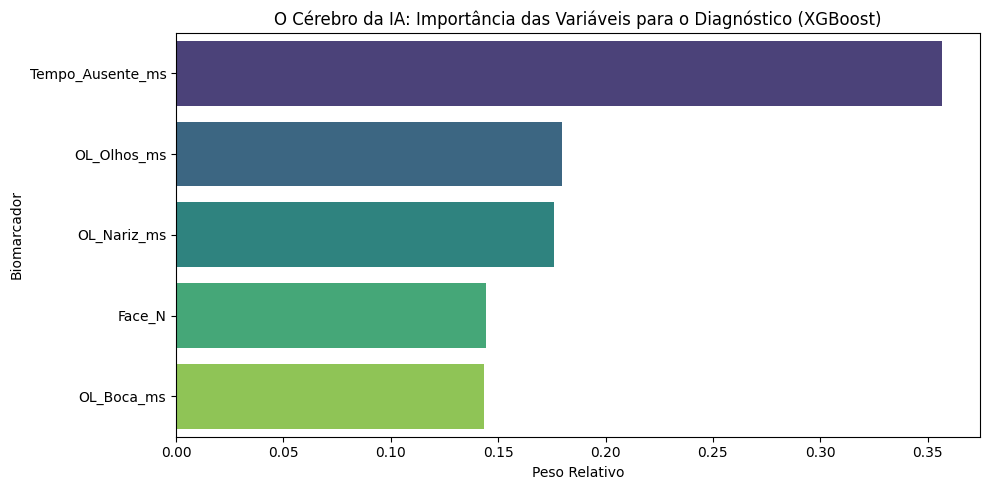

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*80)
print("TREINAMENTO XGBOOST: CLASSIFICAÇÃO COM ISOLAMENTO DE PACIENTES")
print("="*80)

caminho_matriz = '/workspaces/EyeTracking_analysis/reports/Matriz_NEU_51Faces_Completa.csv'

try:
    df = pd.read_csv(caminho_matriz)
    
    # 1. Preparação das Variáveis (Features e Target)
    # Selecionamos apenas os marcadores numéricos do Eye Tracking e o Número da Face
    features = ['Face_N', 'OL_Olhos_ms', 'OL_Nariz_ms', 'OL_Boca_ms', 'Tempo_Ausente_ms']
    X = df[features]
    
    # O nosso Target é o Grupo Clínica (TEA vs CONTROLE)
    le = LabelEncoder()
    y = le.fit_transform(df['Grupo']) # Converte texto para 0 e 1
    
    # O Agrupador (A garantia contra o Vazamento de Dados)
    grupos = df['ID']
    
    # 2. Divisão de Treino e Teste (80% / 20%) isolando por Paciente
    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    
    for indice_treino, indice_teste in gss.split(X, y, groups=grupos):
        X_treino, X_teste = X.iloc[indice_treino], X.iloc[indice_teste]
        y_treino, y_teste = y[indice_treino], y[indice_teste]
        
    print(f"📊 Volume de Treino: {len(X_treino)} vetores")
    print(f"📊 Volume de Teste: {len(X_teste)} vetores (Pacientes inéditos para o modelo)")
    
    # 3. Configuração e Treinamento do Motor XGBoost
    # Parâmetros conservadores para evitar overfitting (memorização)
    modelo_xgb = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    )
    
    print("\n🧠 Treinando o modelo XGBoost...")
    modelo_xgb.fit(X_treino, y_treino)
    
    # 4. Avaliação Implacável (A Prova Final)
    predicoes = modelo_xgb.predict(X_teste)
    acuracia = accuracy_score(y_teste, predicoes)
    
    print("-" * 60)
    print(f"🎯 ACURÁCIA GLOBAL DO MODELO: {acuracia * 100:.2f}%")
    print("-" * 60)
    print("\nDetalhamento do Relatório de Classificação:")
    print(classification_report(y_teste, predicoes, target_names=le.classes_))
    
    # 5. Auditoria de Decisão (Feature Importance)
    # Descobrindo qual variável teve mais peso para a IA tomar a decisão
    importancias = modelo_xgb.feature_importances_
    df_importancias = pd.DataFrame({'Variavel': features, 'Peso': importancias})
    df_importancias = df_importancias.sort_values(by='Peso', ascending=False)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Peso', y='Variavel', data=df_importancias, palette='viridis', hue='Variavel')
    plt.title('O Cérebro da IA: Importância das Variáveis para o Diagnóstico (XGBoost)')
    plt.xlabel('Peso Relativo')
    plt.ylabel('Biomarcador')
    plt.tight_layout()
    
    # Salva o gráfico para a sua dissertação
    caminho_grafico = '/workspaces/EyeTracking_analysis/reports/XGBoost_Feature_Importance.png'
    plt.savefig(caminho_grafico)
    print(f"\n📈 Gráfico de Importância das Variáveis gerado em: {caminho_grafico}")
    plt.show()

except Exception as e:
    print(f"❌ Erro durante o treinamento do modelo: {e}")

In [1]:
import os
import pandas as pd

print("\n" + "="*80)
print("AUDITORIA DE CRUZA DE DADOS: CASO T15")
print("="*80)

PASTA_RAW = '/workspaces/EyeTracking_analysis/data/raw/'
PASTA_LIMPOS = '/workspaces/EyeTracking_analysis/data/csv_limpos/'

# Escanear correspondências para o termo T15 em ambas as pastas
arquivos_raw = [f for f in os.listdir(PASTA_RAW) if 'T15' in f.upper()]
arquivos_limpos = [f for f in os.listdir(PASTA_LIMPOS) if 'T15' in f.upper()]

print("📁 Verificação na Pasta RAW (Origem):")
if not arquivos_raw:
    print(" ⚠️ Nenhum arquivo contendo 'T15' foi encontrado na pasta raw!")
else:
    for arq in arquivos_raw:
        caminho = os.path.join(PASTA_RAW, arq)
        tamanho_kb = os.path.getsize(caminho) / 1024
        print(f" - Arquivo: {arq} | Tamanho Real: {tamanho_kb:.2f} KB")

print("\n📁 Verificação na Pasta CSV_LIMPOS (Destino):")
if not arquivos_limpos:
    print(" ⚠️ Nenhum arquivo contendo 'T15' foi encontrado na pasta limpa!")
else:
    for arq in arquivos_limpos:
        caminho = os.path.join(PASTA_LIMPOS, arq)
        tamanho_kb = os.path.getsize(caminho) / 1024
        try:
            df_teste = pd.read_csv(caminho)
            total_linhas = len(df_teste)
            colunas = list(df_teste.columns)
        except Exception as e:
            total_linhas = f"Erro na leitura ({e})"
            colunas = []
        print(f" - Arquivo: {arq} | Tamanho: {tamanho_kb:.2f} KB | Linhas Detectadas: {total_linhas}")
        print(f"   Colunas no CSV: {colunas}")

print("="*80)


AUDITORIA DE CRUZA DE DADOS: CASO T15
📁 Verificação na Pasta RAW (Origem):
 - Arquivo: T15 TEA MODERADO.xlsx | Tamanho Real: 778.78 KB

📁 Verificação na Pasta CSV_LIMPOS (Destino):
 - Arquivo: T15 TEA MODERADO.csv | Tamanho: 227.22 KB | Linhas Detectadas: 11951
   Colunas no CSV: ['Time (ms)', 'Timegap (ms)', 'Gaze X', 'Gaze Y', 'AOI']


In [3]:
import pandas as pd
import os

print("\n" + "="*80)
print("TESTE DE REALIDADE: ABRINDO O FICHEIRO BRUTO DO T15")
print("="*80)

caminho_raw_t15 = '/workspaces/EyeTracking_analysis/data/raw/T15 TEA MODERADO.xlsx'

if not os.path.exists(caminho_raw_t15):
    print("❌ O ficheiro não foi encontrado na pasta raw.")
else:
    try:
        tamanho_kb = os.path.getsize(caminho_raw_t15) / 1024
        print(f"📦 Tamanho Físico Confirmado no Disco Local: {tamanho_kb:.2f} KB\n")
        
        print("Lendo o conteúdo do Excel (isto pode demorar alguns segundos)...\n")
        
        # Lemos o ficheiro bruto exatamente como ele veio do laboratório
        df_t15_bruto = pd.read_excel(caminho_raw_t15)
        
        print("✅ FICHEIRO ABERTO COM SUCESSO!\n")
        print(f"Total de linhas reais dentro do Excel: {len(df_t15_bruto)}")
        
        print("\nPrimeiras 5 linhas do ficheiro (Início da Gravação):")
        # Mostramos as colunas essenciais para provar que os dados existem
        display(df_t15_bruto[['Time (ms)', 'Gaze X', 'Gaze Y']].head())
        
        print("\nÚltimas 5 linhas do ficheiro (Fim da Gravação):")
        display(df_t15_bruto[['Time (ms)', 'Gaze X', 'Gaze Y']].tail())

    except Exception as e:
        print(f"❌ Erro ao tentar ler o conteúdo do ficheiro: {e}")

print("="*80)


TESTE DE REALIDADE: ABRINDO O FICHEIRO BRUTO DO T15
📦 Tamanho Físico Confirmado no Disco Local: 778.78 KB

Lendo o conteúdo do Excel (isto pode demorar alguns segundos)...

✅ FICHEIRO ABERTO COM SUCESSO!

Total de linhas reais dentro do Excel: 11951

Primeiras 5 linhas do ficheiro (Início da Gravação):


,Time (ms),Gaze X,Gaze Y
0,0,462,983
1,17,412,883
2,33,391,853
3,50,394,867
4,67,392,858



Últimas 5 linhas do ficheiro (Fim da Gravação):


,Time (ms),Gaze X,Gaze Y
11946,202931,473,441
11947,202948,477,426
11948,202964,483,442
11949,202981,474,439
11950,202998,481,431


--> RELATÓRIO REUNIÃO (27/05)

Faces mapeadas

In [1]:
import pandas as pd
import os
import glob
import math

print("\n" + "="*80)
print("AUDITORIA: VERIFICAÇÃO DAS 60 FACES")
print("="*80)

PASTA_LIMPOS = '/workspaces/EyeTracking_analysis/data/csv_limpos/'
arquivos_csv = glob.glob(os.path.join(PASTA_LIMPOS, '*.csv'))

resultados = []

for caminho in arquivos_csv:
    nome_arquivo = os.path.basename(caminho).replace('.csv', '')
    
    # Ignoramos o T12
    if "T12" in nome_arquivo.upper():
        continue
        
    try:
        df = pd.read_csv(caminho)
        
        # Ponto Zero
        linhas_validas = df[df['AOI'] > 0]
        
        if linhas_validas.empty:
            continue
            
        ponto_zero = linhas_validas['Time (ms)'].iloc[0]
        tempo_final = df['Time (ms)'].max()
        
        # O cálculo puro sem travas ou cortes
        tempo_util = tempo_final - ponto_zero
        faces_calculadas = math.ceil(tempo_util / 4000)
        
        resultados.append({
            'Paciente': nome_arquivo, 
            'Tempo_Util_ms': tempo_util,
            'Faces_Reais_Gravadas': faces_calculadas
        })
        
    except Exception as e:
        print(f"Erro em {nome_arquivo}: {e}")

df_auditoria = pd.DataFrame(resultados)

# Ordenamos do maior para o menor para ver se alguém bateu 60
df_auditoria = df_auditoria.sort_values(by=['Faces_Reais_Gravadas', 'Paciente'], ascending=[False, True]).reset_index(drop=True)

print("📊 TABELA DA QTD MÁXIMA:")
display(df_auditoria.head(15)) # Mostra os maiores resultados

# Geração das provas estatísticas
maximo_absoluto = df_auditoria['Faces_Reais_Gravadas'].max()
pacientes_com_60 = (df_auditoria['Faces_Reais_Gravadas'] >= 60).sum()
pacientes_na_faixa_50 = ((df_auditoria['Faces_Reais_Gravadas'] >= 50) & (df_auditoria['Faces_Reais_Gravadas'] <= 52)).sum()

print("\n" + "-"*80)
print("VEREDITO DA HIPÓTESE:")
print(f"Máximo absoluto alcançado na amostra: {maximo_absoluto} faces")
print(f"✔️ Pacientes que atingiram 60 faces: {pacientes_com_60}")
print(f"✔️ Pacientes que pararam entre 50 a 52 faces: {pacientes_na_faixa_50}")
print("-" * 80)


AUDITORIA: VERIFICAÇÃO DAS 60 FACES
📊 TABELA DA QTD MÁXIMA:


,Paciente,Tempo_Util_ms,Faces_Reais_Gravadas
0,T 24 TEA LEVE,203813,51
1,T15 TEA MODERADO,202499,51
2,T16 TEA LEVE,203912,51
3,T17 TEA LEVE,203846,51
4,T18 TEA MODERADO,202549,51
5,T191 TEA MODERADO,203929,51
6,T20 TEA MODERADO,202283,51
7,T21 TEA MODERADO,203879,51
8,T22 TEA MODERADO,203380,51
9,T25 TEA LEVE,203846,51



--------------------------------------------------------------------------------
VEREDITO DA HIPÓTESE:
Máximo absoluto alcançado na amostra: 51 faces
✔️ Pacientes que atingiram 60 faces: 0
✔️ Pacientes que pararam entre 50 a 52 faces: 40
--------------------------------------------------------------------------------


SIMULADOR - CORTE (40 PARTICIPANTES)

In [6]:
import pandas as pd
import os
import glob

print("RELATÓRIO: QUALIDADE DE AMOSTRAGEM (LINHAS)")

PASTA_LIMPOS = '/workspaces/EyeTracking_analysis/data/csv_limpos/'
PASTA_REPORTS = '/workspaces/EyeTracking_analysis/reports/'
os.makedirs(PASTA_REPORTS, exist_ok=True)

arquivos_limpos = glob.glob(os.path.join(PASTA_LIMPOS, '*.csv'))
relatorio = []

print("Processando os arquivos CSV...")

for caminho in arquivos_limpos:
    nome_arquivo = os.path.basename(caminho)
    nome_puro = nome_arquivo.replace('.csv', '')
    
    # Ignorar o T12 corrompido
    if "T12" in nome_puro.upper():
        continue
        
    try:
        # Lendo o arquivo final que alimentará o modelo
        df = pd.read_csv(caminho)
        total_linhas = len(df)
        tamanho_kb = os.path.getsize(caminho) / 1024
        grupo = "TEA" if "TEA" in nome_puro.upper() else "CONTROLE"
        
        # Classificação baseada no ideal de ~12.000 amostras úteis (60Hz * 200s)
        if total_linhas > 10000:
            status = "🟢 Bom (>80%)"
        elif total_linhas > 6000:
            status = "🟡 Aceitável (>50%)"
        else:
            status = "🔴 Amostragem Reduzida (<50%)"
            
        relatorio.append({
            'Paciente': nome_puro,
            'Grupo': grupo,
            'Total_Linhas_Limpas': total_linhas,
            'Tamanho_Físico_CSV (KB)': round(tamanho_kb, 1),
            'Status de Coleta': status
        })
    except Exception as e:
        relatorio.append({
            'Paciente': nome_puro,
            'Grupo': 'ERRO',
            'Total_Linhas_Limpas': 0,
            'Tamanho_Físico_CSV (KB)': 0,
            'Status de Coleta': f'Erro na leitura: {str(e)[:20]}'
        })

# Estruturando os dados
df_relatorio = pd.DataFrame(relatorio)

# Ordenando para facilitar a visualização (Primeiro TEA/CONTROLE, depois as menores amostragens no topo)
df_relatorio = df_relatorio.sort_values(by=['Grupo', 'Total_Linhas_Limpas']).reset_index(drop=True)

# 1. Impressão no Terminal
print("\n TABELA DE LINHAS ÚTEIS (Por Grupo):")
display(df_relatorio)

# 2. Exportação do Arquivo Físico
caminho_excel = os.path.join(PASTA_REPORTS, 'Relatorio_Linhas_CSV_Limpos.xlsx')
df_relatorio.to_excel(caminho_excel, index=False)

print(f" Relatório Excel completo (baseado nos dados limpos) salvo em: {caminho_excel}")

RELATÓRIO: QUALIDADE DE AMOSTRAGEM (LINHAS)
Processando os arquivos CSV...

 TABELA DE LINHAS ÚTEIS (Por Grupo):


,Paciente,Grupo,Total_Linhas_Limpas,Tamanho_Físico_CSV (KB),Status de Coleta
0,T41 CONTROLE,CONTROLE,9425,178.1,🟡 Aceitável (>50%)
1,T36 CONTROLE,CONTROLE,9995,190.1,🟡 Aceitável (>50%)
2,T38 CONTROLE,CONTROLE,10365,196.1,🟢 Bom (>80%)
3,T44 CONTROLE,CONTROLE,10968,207.9,🟢 Bom (>80%)
4,T47 CONTROLE,CONTROLE,10970,208.5,🟢 Bom (>80%)
5,T37 CONTROLE,CONTROLE,11000,209.1,🟢 Bom (>80%)
6,T43 CONTROLE,CONTROLE,11061,210.3,🟢 Bom (>80%)
7,T58 CONTROLE,CONTROLE,11142,211.9,🟢 Bom (>80%)
8,T42 CONTROLE,CONTROLE,11325,215.1,🟢 Bom (>80%)
9,T60 CONTROLE,CONTROLE,11426,217.1,🟢 Bom (>80%)


 Relatório Excel completo (baseado nos dados limpos) salvo em: /workspaces/EyeTracking_analysis/reports/Relatorio_Linhas_CSV_Limpos.xlsx


In [1]:
import pandas as pd
import os

print("\n" + "="*80)
print("VERIFICAÇÃO REAL DO PACIENTE T16 NO CODESPACE")
print("="*80)

caminho_t16 = '/workspaces/EyeTracking_analysis/data/raw/T16 TEA LEVE.xlsx'

if not os.path.exists(caminho_t16):
    print("❌ O arquivo T16 TEA LEVE.xlsx não foi encontrado na pasta raw do Codespace.")
else:
    try:
        # Lendo o arquivo real armazenado no disco do Codespace
        df_t16 = pd.read_excel(caminho_t16)
        total_linhas_local = len(df_t16)
        
        print(f"📊 Linhas detectadas no CODESPACE: {total_linhas_local}")
        print(f"📊 Linhas que você viu no DRIVE: 11954")
        
        print("\n🔍 VEREDITO:")
        if total_linhas_local == 11954:
            print("  ✅ Tudo perfeito! O arquivo local está idêntico ao do Google Drive.")
            print("  A minha suposição de 'Data Loss' para o T16 estava completamente errada.")
        else:
            print("  ⚠️ Há uma divergência! O arquivo no Codespace está menor do que no Drive.")
            print("  Isso significa que o download falhou ou o arquivo foi cortado pela metade ao ser transferido.")

    except Exception as e:
        print(f"❌ Erro ao tentar ler o arquivo: {e}")

print("="*80)


VERIFICAÇÃO REAL DO PACIENTE T16 NO CODESPACE
📊 Linhas detectadas no CODESPACE: 3249
📊 Linhas que você viu no DRIVE: 11954

🔍 VEREDITO:
  ⚠️ Há uma divergência! O arquivo no Codespace está menor do que no Drive.
  Isso significa que o download falhou ou o arquivo foi cortado pela metade ao ser transferido.
